#  Energy Consumption Analysis — Nexus Elante Mall, Chandigarh
---
| | |
|---|---|
| **Author** | Navjot Singh |
| **Project** | Major Project — Machine Learning & Data Analytics |
| **Dataset** | Nexus Elante Mall, Chandigarh (2019–2025) |
| **Date** | 2025 |

---
###  Objective
Analyse **7 years** (2019–2025) of monthly power consumption data for Nexus Elante Mall.  
Build ML regression models to **predict energy consumption** and **forecast 2025 demand**.

###  Complete Pipeline
```
Load Data (7 files)
    → Clean & Preprocess
        → EDA & Visualisation (10 charts)
            → Correlation Analysis
                → Feature Engineering (seasonal + lag)
                    → Model Training (Ridge + Gradient Boosting)
                        → LOOCV Evaluation
                            → 2025 Forecasting
```
---
>  **Setup:** Place all 7 `.xlsb` files (2019–2025) in the **same folder** as this notebook, then run all cells.


---
##  Step 1 — Import Libraries

In [1]:
import warnings, re
from pathlib import Path

import numpy  as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn           as sns

from sklearn.linear_model    import RidgeCV
from sklearn.ensemble        import GradientBoostingRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics         import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 30)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']       = 120
plt.rcParams['figure.facecolor'] = 'white'

print(f"  Libraries loaded.")
print(f"    NumPy  {np.__version__}  |  Pandas {pd.__version__}")


  Libraries loaded.
    NumPy  2.4.2  |  Pandas 3.0.1


---
##  Step 2 — Load All Data Files (2019–2025)

The loader:
- Scans the current folder for every `.xlsb / .xlsx / .xls / .csv` file
- Auto-detects the **year** embedded in each file
- Handles both single-level and multi-level header layouts
- Reports every file it loads (or skips)


In [2]:
DATA_DIR       = Path('.')
SUPPORTED_EXTS = {'.csv', '.xlsx', '.xls', '.xlsb'}

MONTH_ORDER = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# ── Helpers ───────────────────────────────────────────────────────────────────
def _read_raw(fp):
    ext = fp.suffix.lower()
    if ext == '.csv':
        return pd.read_csv(fp, header=None, dtype=str)
    if ext == '.xlsb':
        try:
            return pd.read_excel(fp, header=None, dtype=str, engine='pyxlsb')
        except ImportError:
            raise ImportError("Run:  pip install pyxlsb")
    return pd.read_excel(fp, header=None, dtype=str)

def _find_year(raw, fp):
    for _, row in raw.iterrows():
        for v in row:
            m = re.search(r'\b(20\d{2})\b', str(v))
            if m: return int(m.group(1))
    m = re.search(r'\b(20\d{2})\b', fp.stem)
    return int(m.group(1)) if m else 0

def _months_row(raw):
    for i, row in raw.iterrows():
        for v in row:
            if str(v).strip().lower() == 'months': return i
    return None

def _load_file(fp):
    raw      = _read_raw(fp)
    year     = _find_year(raw, fp)
    hdr_row  = _months_row(raw)
    if hdr_row is None:
        return None, year, "no 'Months' row found"

    kw = {'engine':'pyxlsb'} if fp.suffix.lower()=='.xlsb' else {}
    df = pd.read_excel(fp, header=hdr_row, **kw) if fp.suffix.lower()!='.csv'          else pd.read_csv(fp, header=hdr_row)

    df.columns   = [str(c).strip() for c in df.columns]
    df['Months'] = df['Months'].astype(str).str.strip()
    df           = df[df['Months'].isin(MONTH_ORDER)].copy()
    df['Month_Num'] = df['Months'].map({m:i+1 for i,m in enumerate(MONTH_ORDER)})
    df['Year']      = year

    # Normalise total-consumption column name
    for alias in ['Total','Grand Total','Total EB','Total Consumption','Total  EB']:
        if alias in df.columns:
            df.rename(columns={alias:'Consumption'}, inplace=True)
            break

    return df, year, None

# ── Scan & Load ───────────────────────────────────────────────────────────────
files    = sorted([f for f in DATA_DIR.iterdir()
                   if f.suffix.lower() in SUPPORTED_EXTS
                   and not f.name.startswith('~')])
datasets = {}

print(f"Found {len(files)} file(s):\n")
for fp in files:
    try:
        df, year, err = _load_file(fp)
        if err:
            print(f"  ⚠️  Skipped  {fp.name[:60]}  ({err})")
        else:
            datasets[year] = df
            print(f"    {str(year)}  |  {df.shape[0]} rows × {df.shape[1]} cols  |  {fp.name[:55]}")
    except Exception as e:
        print(f"    Error — {fp.name}: {e}")

print(f"\n  Years loaded: {sorted(datasets.keys())}")


Found 7 file(s):

    2019  |  12 rows × 21 cols  |  2019 EB Power Consumptions Analisys for Nexus Elante Ma
    2020  |  12 rows × 21 cols  |  2020 EB Power Consumptions Analisys for Nexus Elante Ma
    2021  |  12 rows × 21 cols  |  2021 EB Power Consumptions Analisys for Nexus Elante Ma
    2022  |  12 rows × 21 cols  |  2022 EB Power Consumptions Analysis for Nexus Elante Ma
    2023  |  12 rows × 21 cols  |  2023 EB Power Consumptions Analysis for Nexus Elante Ma
    2024  |  12 rows × 24 cols  |  2024 EB Power Consumptions Analysis for Nexus Elante Ma
    2025  |  12 rows × 24 cols  |  2025 Power Consumptions Analysis for Nexus Elante Mall 

  Years loaded: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


---
##  Step 3 — Data Cleaning & Preprocessing

For each year's dataset:
1. Convert all non-identifier columns to **numeric**
2. Drop **all-NaN** and **zero-variance** columns
3. Fill remaining NaN values with column **median** (robust to outliers)
4. Remove rows where **Consumption** is missing


In [3]:
ID_COLS = {'Months', 'Year', 'Month_Num'}

def clean_df(df):
    df = df.copy()
    for col in df.columns:
        if col not in ID_COLS:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',','').str.strip(), errors='coerce')

    df.dropna(axis=1, how='all', inplace=True)

    num_cols = df.select_dtypes(include='number').columns
    zero_var = [c for c in num_cols if c not in ID_COLS and df[c].std()==0]
    if zero_var:
        print(f"    Dropping zero-variance: {zero_var}")
    df.drop(columns=zero_var, inplace=True)

    if 'Consumption' in df.columns:
        before = len(df)
        df.dropna(subset=['Consumption'], inplace=True)
        dropped = before - len(df)
        if dropped: print(f"    Dropped {dropped} row(s) with missing Consumption.")

    num_cols = [c for c in df.select_dtypes(include='number').columns if c not in ID_COLS]
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    return df.reset_index(drop=True)

cleaned = {}
for year, df in sorted(datasets.items()):
    print(f"\n🔧  Cleaning {year}:")
    cleaned[year] = clean_df(df)

# ── Combined DataFrame (Consumption + metadata only — common across all years)
df_combined = pd.concat(
    [df[['Year','Month_Num','Months','Consumption']] for df in cleaned.values()
     if 'Consumption' in df.columns],
    ignore_index=True
).sort_values(['Year','Month_Num']).reset_index(drop=True)

print(f"\n  Combined dataset: {df_combined.shape[0]} rows × {df_combined.shape[1]} cols")
print(df_combined.head(4).to_string(index=False))



🔧  Cleaning 2019:

🔧  Cleaning 2020:
    Dropping zero-variance: ['Hotel  Solar']

🔧  Cleaning 2021:
    Dropping zero-variance: ['Hotel  Solar']

🔧  Cleaning 2022:

🔧  Cleaning 2023:

🔧  Cleaning 2024:

🔧  Cleaning 2025:
    Dropping zero-variance: ['DG.4', 'DG.6']
    Dropped 6 row(s) with missing Consumption.

  Combined dataset: 78 rows × 4 cols
 Year  Month_Num   Months  Consumption
 2019          1  January    2,130,000
 2019          2 February    1,988,000
 2019          3    March    2,294,000
 2019          4    April    3,102,000


---
##  Step 4 — Data Summary per Year

In [4]:
for year, df in sorted(cleaned.items()):
    print(f"\n{'─'*65}")
    print(f"  {year}  |  Shape: {df.shape}")
    print(f"{'─'*65}")
    num_df = df.select_dtypes(include='number').drop(
        columns=[c for c in ['Year','Month_Num'] if c in df.columns])
    print(num_df.describe().T[['count','mean','std','min','max']].to_string())



─────────────────────────────────────────────────────────────────
  2019  |  Shape: (12, 19)
─────────────────────────────────────────────────────────────────
              count      mean     std       min       max
Consumption      12 2,930,833 713,916 1,988,000 4,143,000
Mall Solar       12    29,519  10,606    17,567    49,540
Mall             12 2,285,203 545,538 1,565,406 2,968,891
Mall DG          12    21,608  29,563         0    97,856
Tenant           12 1,148,077  92,290   937,003 1,266,180
Tenant  DG       12    11,241  15,985         0    57,347
HVAC             12   743,312 428,539   220,805 1,305,763
HVAC DG          12     6,428   9,180         0    30,101
CA  Lighting     12   423,334  48,830   340,568   489,622
CA DG            12     3,939   7,230         0    25,397
OB Solar         12     1,449   1,635         0     4,903
OB               12   199,396  33,814   152,750   257,669
OB DG            12     1,449   1,635         0     4,903
Hotel  Solar     12    10,24

---
##  Step 5 — Exploratory Data Analysis (EDA)

### 5a — Monthly Consumption Trend — All Years Overlaid

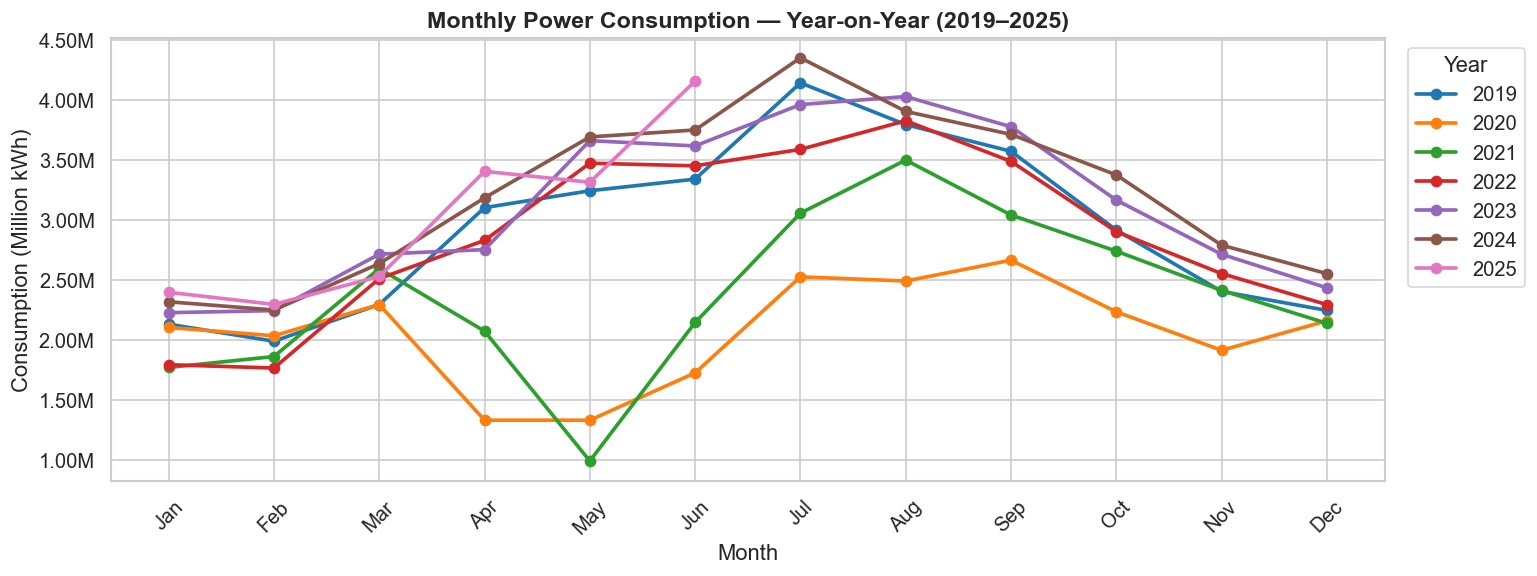

  Saved: plot_01_monthly_trend.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette('tab10', n_colors=len(cleaned))

for (year, df), color in zip(sorted(cleaned.items()), palette):
    df_s = df.sort_values('Month_Num')
    ax.plot(df_s['Month_Num'], df_s['Consumption']/1e6,
            marker='o', linewidth=2.2, label=str(year), color=color)

ax.set_xticks(range(1,13))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.2f}M"))
ax.set_title('Monthly Power Consumption — Year-on-Year (2019–2025)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Consumption (Million kWh)')
ax.legend(title='Year', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('plot_01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: plot_01_monthly_trend.png")


### 5b — Annual Total Consumption with YoY Growth Rate

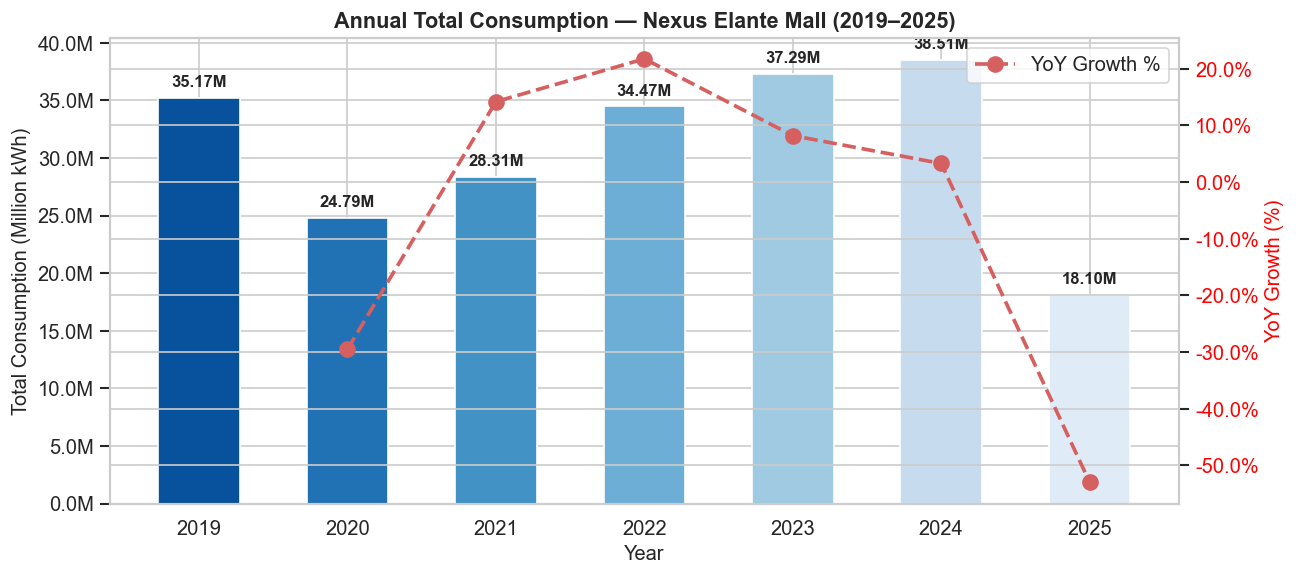

  Saved: plot_02_annual_yoy.png
 Year  Consumption  Growth_pct
 2019   35,170,000         NaN
 2020   24,794,000         -30
 2021   28,312,000          14
 2022   34,469,000          22
 2023   37,292,000           8
 2024   38,512,000           3
 2025   18,096,000         -53


In [6]:
annual = (df_combined.groupby('Year')['Consumption']
          .sum().reset_index().sort_values('Year'))
annual['Growth_pct'] = annual['Consumption'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Blues_r', len(annual))
bars   = ax1.bar(annual['Year'].astype(str), annual['Consumption']/1e6,
                 color=colors, width=0.55, edgecolor='white')
ax1.bar_label(bars, fmt=lambda x: f"{x:.2f}M", padding=5, fontsize=10, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.1f}M"))
ax1.set_ylabel('Total Consumption (Million kWh)', fontsize=12)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_title('Annual Total Consumption — Nexus Elante Mall (2019–2025)',
              fontsize=13, fontweight='bold')

ax2 = ax1.twinx()
valid = annual.dropna(subset=['Growth_pct'])
ax2.plot(valid['Year'].astype(str), valid['Growth_pct'],
         'ro--', linewidth=2.2, markersize=9, label='YoY Growth %')
ax2.set_ylabel('YoY Growth (%)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.1f}%"))
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('plot_02_annual_yoy.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: plot_02_annual_yoy.png")
print(annual.to_string(index=False))


### 5c — Monthly Consumption Heatmap (All Years)

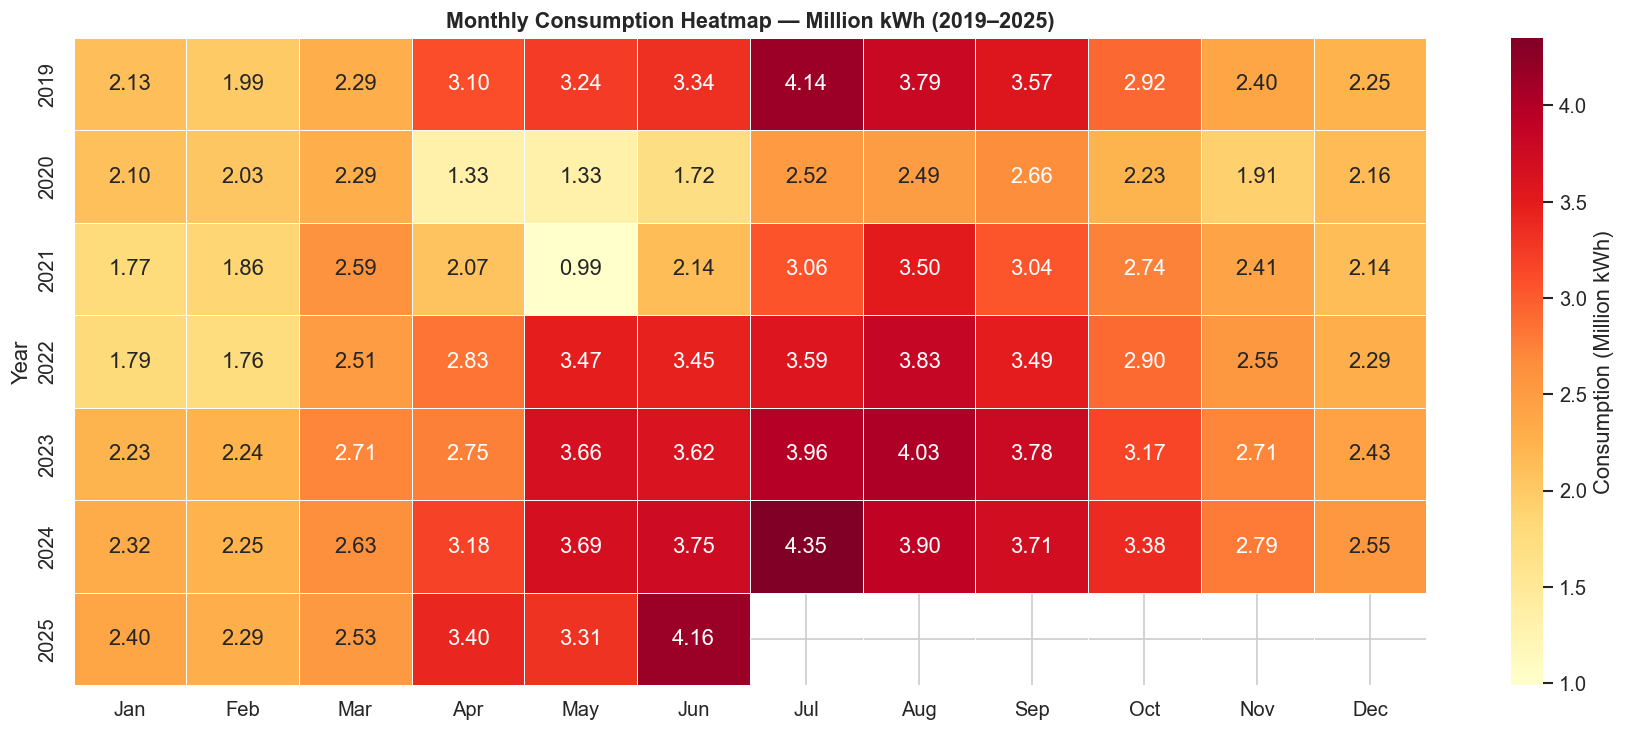

✅  Saved: plot_03_heatmap.png


In [7]:
pivot = df_combined.pivot_table(
    index='Year', columns='Month_Num', values='Consumption', aggfunc='sum')
pivot.columns = [MONTH_ORDER[i-1][:3] for i in pivot.columns]

fig, ax = plt.subplots(figsize=(15, max(4, len(pivot)*0.9)))
sns.heatmap(pivot/1e6, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label':'Consumption (Million kWh)'})
ax.set_title('Monthly Consumption Heatmap — Million kWh (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Year'); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('plot_03_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_03_heatmap.png")


### 5d — Distribution of Monthly Consumption per Year (Box Plot)

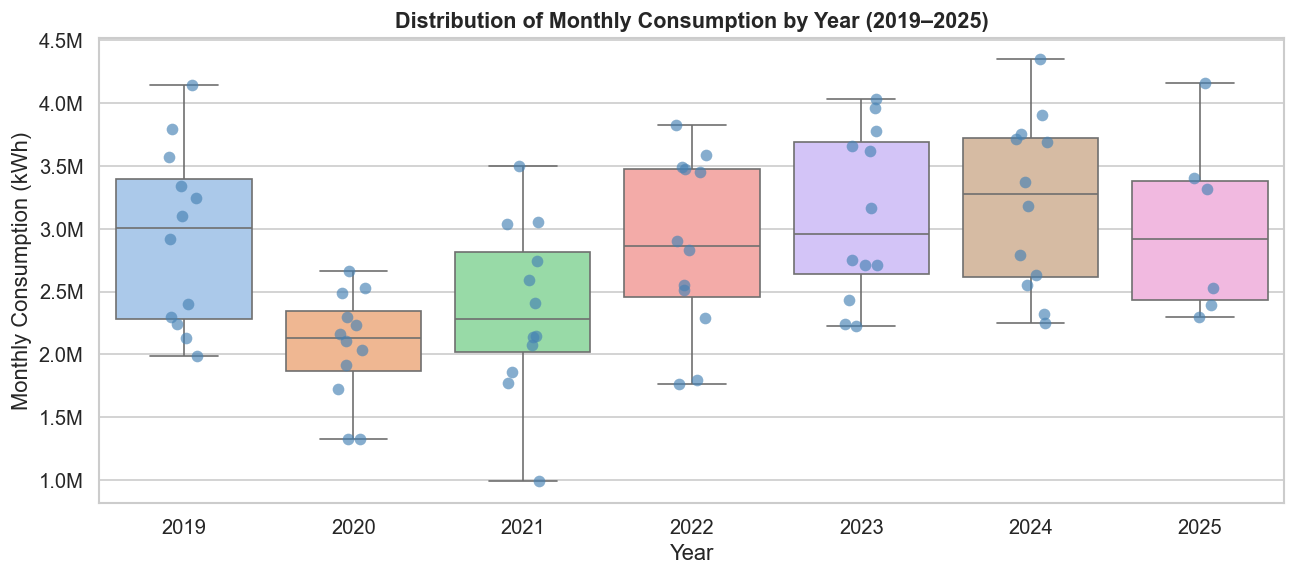

✅  Saved: plot_04_boxplot.png


In [8]:
df_box = df_combined[['Year','Consumption']].copy()
df_box['Year'] = df_box['Year'].astype(str)

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_box,  x='Year', y='Consumption', palette='pastel', ax=ax)
sns.stripplot(data=df_box, x='Year', y='Consumption',
              color='steelblue', alpha=0.65, jitter=True, ax=ax, size=7)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
ax.set_title('Distribution of Monthly Consumption by Year (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Monthly Consumption (kWh)')
plt.tight_layout()
plt.savefig('plot_04_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_04_boxplot.png")


### 5e — Peak vs Low Month Analysis

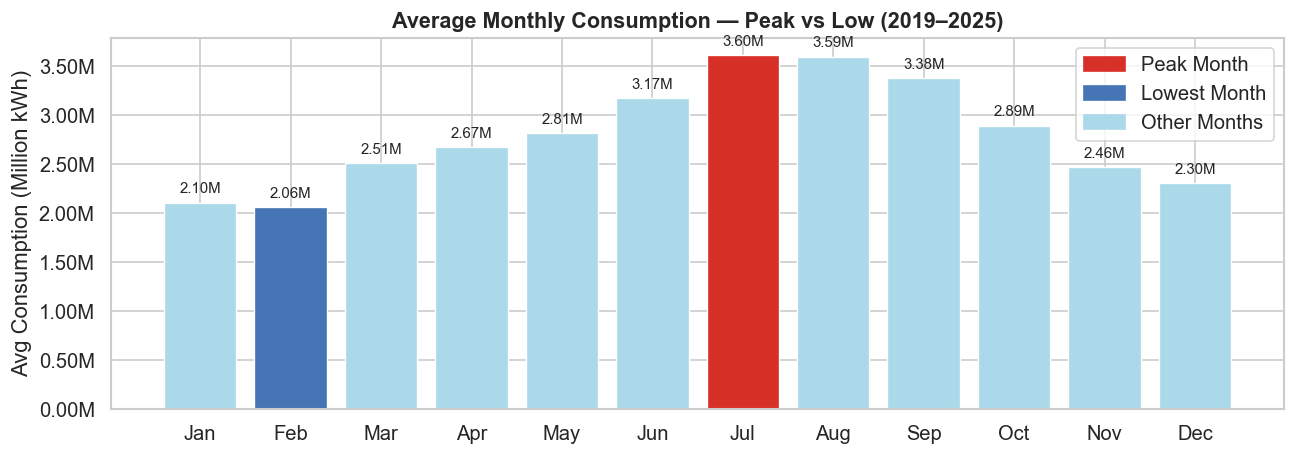

✅  Saved: plot_05_peak_months.png
   🔴 Peak month  : July
   🔵 Lowest month: February


In [9]:
peak = (df_combined.groupby('Month_Num')['Consumption']
        .mean().reset_index())
peak['Month'] = peak['Month_Num'].apply(lambda x: MONTH_ORDER[x-1][:3])
peak_max      = peak['Consumption'].max()
peak_min      = peak['Consumption'].min()

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = ['#d73027' if v==peak_max else '#4575b4' if v==peak_min
              else '#abd9e9' for v in peak['Consumption']]
bars = ax.bar(peak['Month'], peak['Consumption']/1e6,
              color=bar_colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt=lambda x: f"{x:.2f}M", padding=4, fontsize=9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.2f}M"))
ax.set_title('Average Monthly Consumption — Peak vs Low (2019–2025)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Consumption (Million kWh)')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#d73027',label='Peak Month'),
                   Patch(color='#4575b4',label='Lowest Month'),
                   Patch(color='#abd9e9',label='Other Months')])
plt.tight_layout()
plt.savefig('plot_05_peak_months.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_05_peak_months.png")
peak_month = MONTH_ORDER[int(peak.loc[peak['Consumption'].idxmax(),'Month_Num'])-1]
low_month  = MONTH_ORDER[int(peak.loc[peak['Consumption'].idxmin(),'Month_Num'])-1]
print(f"   🔴 Peak month  : {peak_month}")
print(f"   🔵 Lowest month: {low_month}")


---
## 🔗 Step 6 — Correlation Analysis

Pearson correlation heatmap for each year — shows which sub-meters are most strongly related to total consumption.

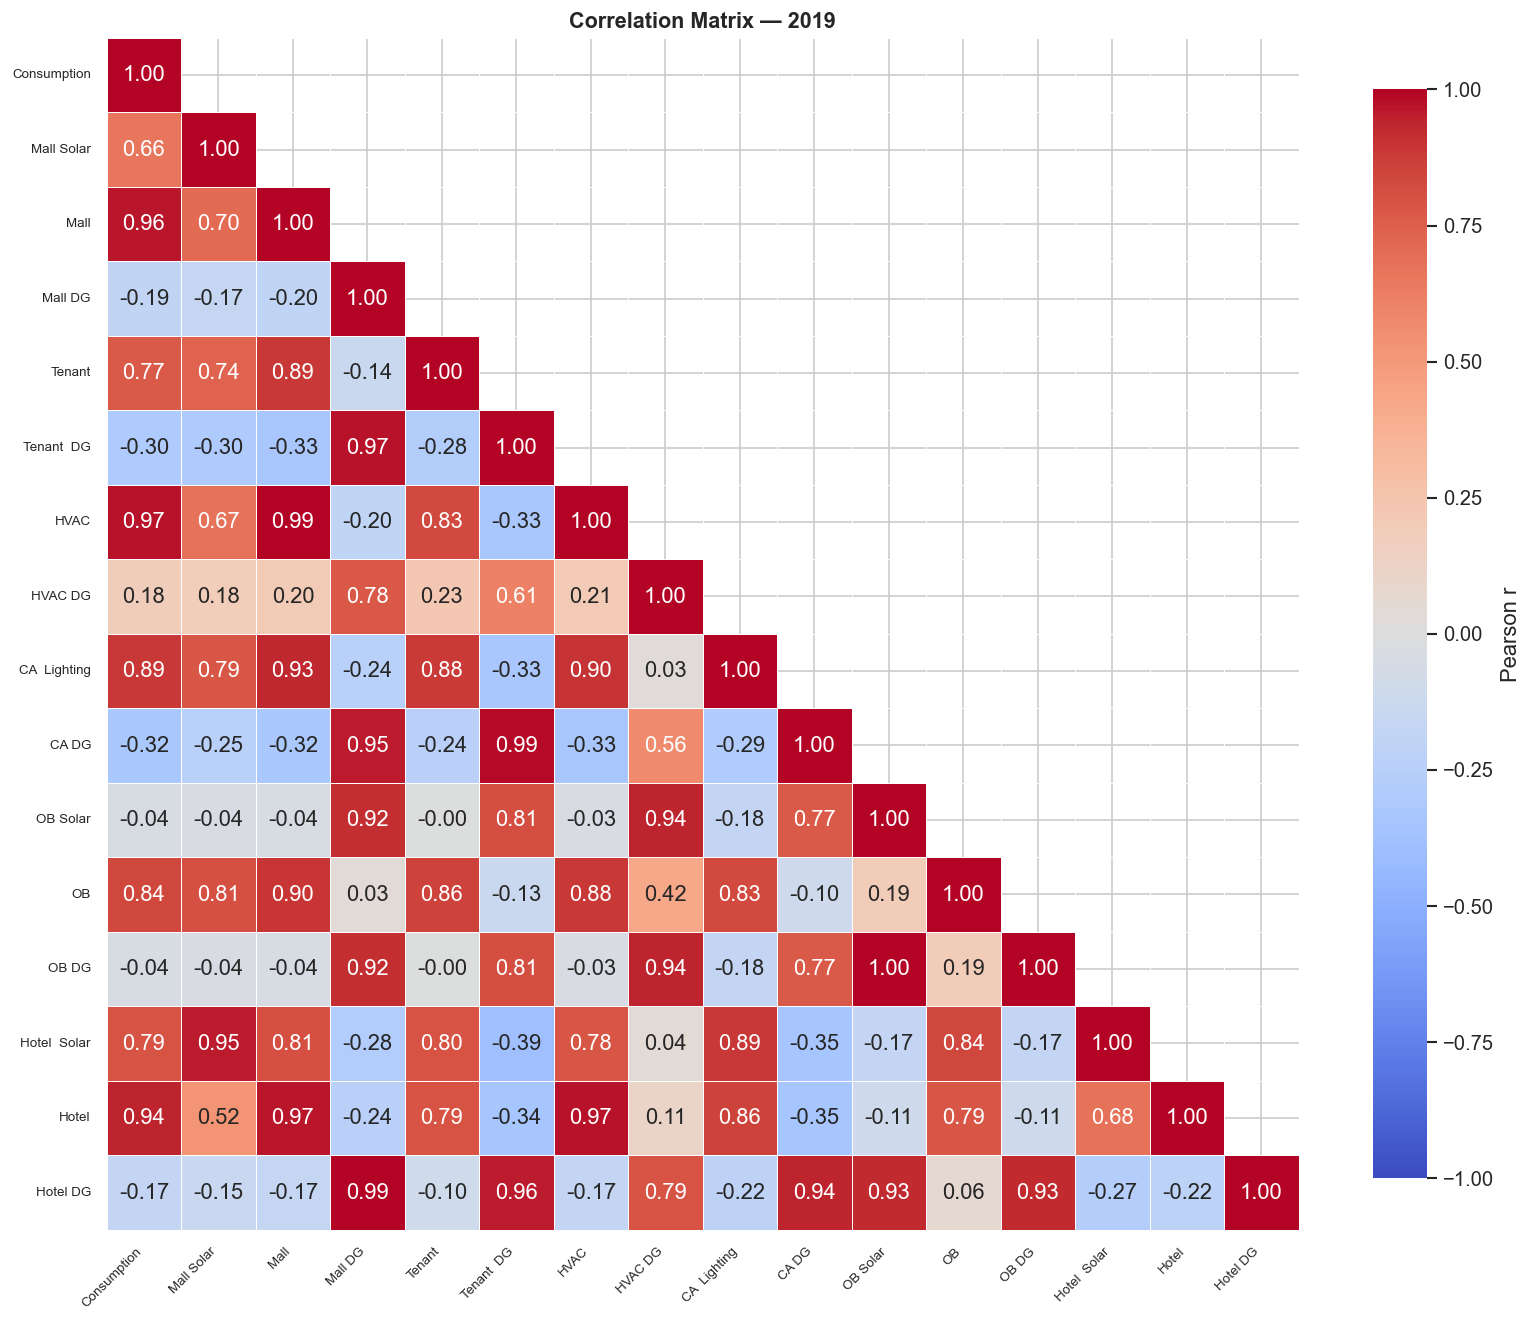

  Saved: plot_06_corr_2019.png
   Top correlations with Consumption (2019):
     +0.974  HVAC
     +0.961  Mall
     +0.944  Hotel
     +0.887  CA  Lighting
     +0.842  OB
     +0.793  Hotel  Solar


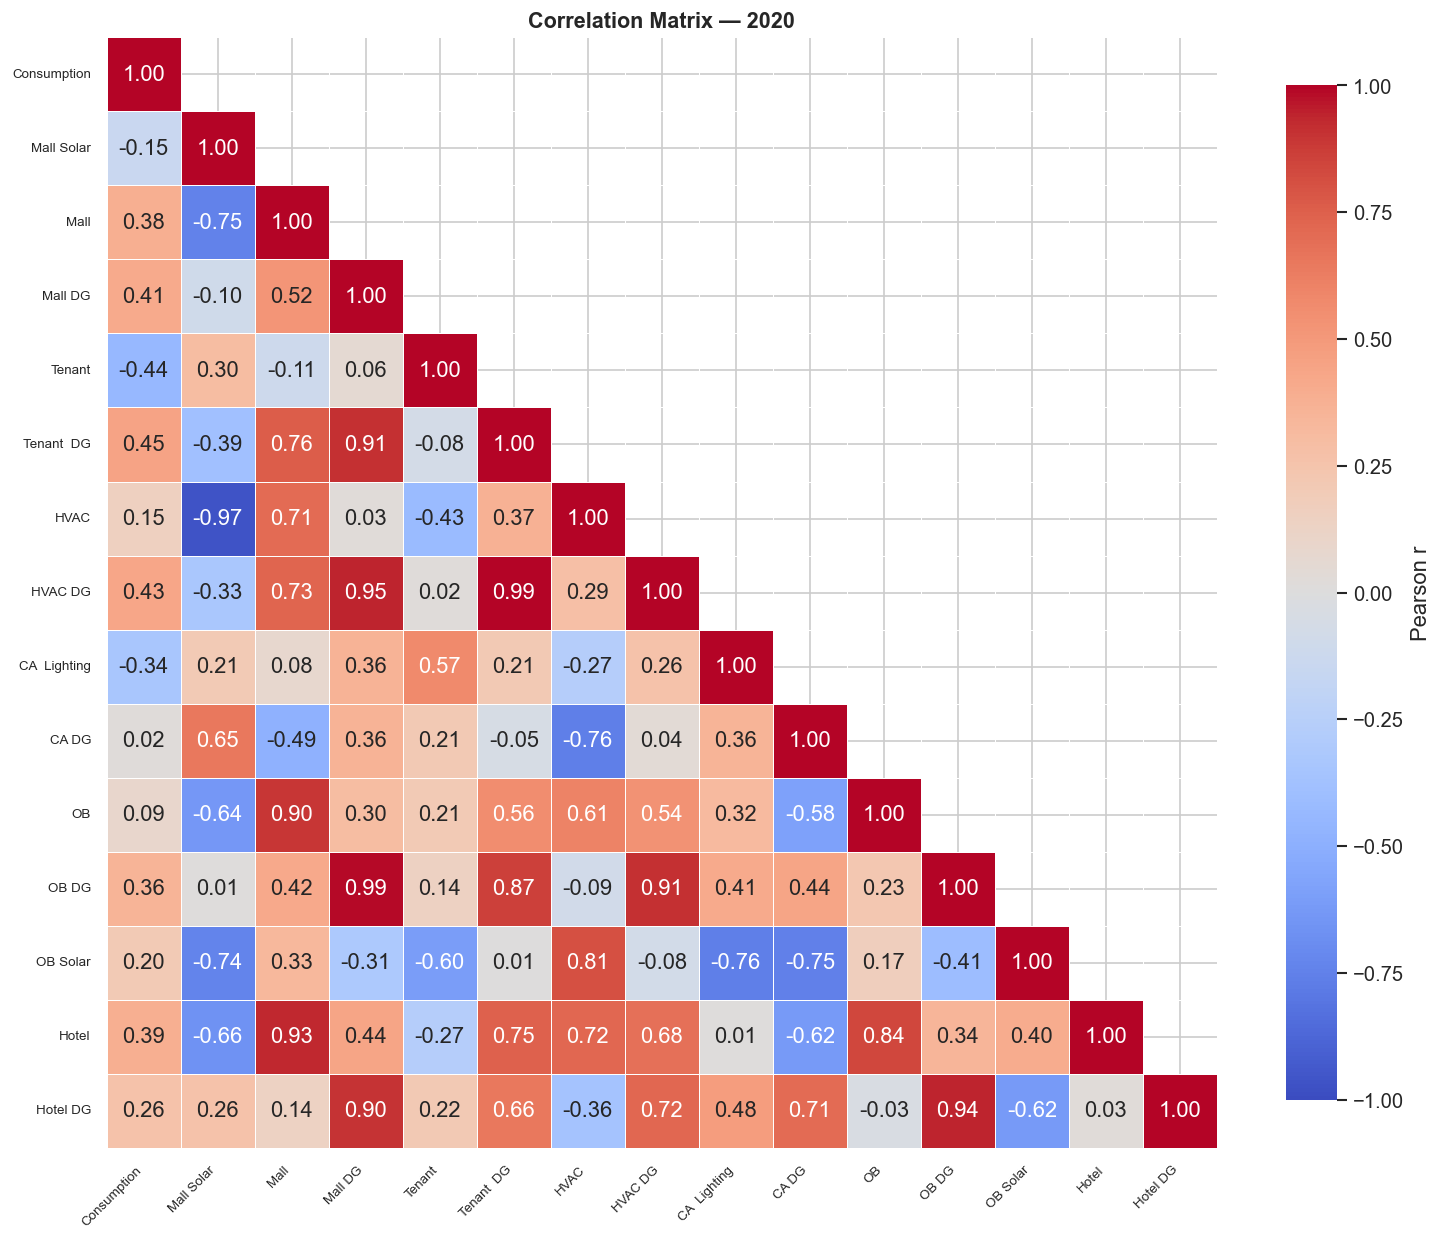

  Saved: plot_06_corr_2020.png
   Top correlations with Consumption (2020):
     +0.452  Tenant  DG
     -0.442  Tenant
     +0.430  HVAC DG
     +0.411  Mall DG
     +0.388  Hotel
     +0.384  Mall


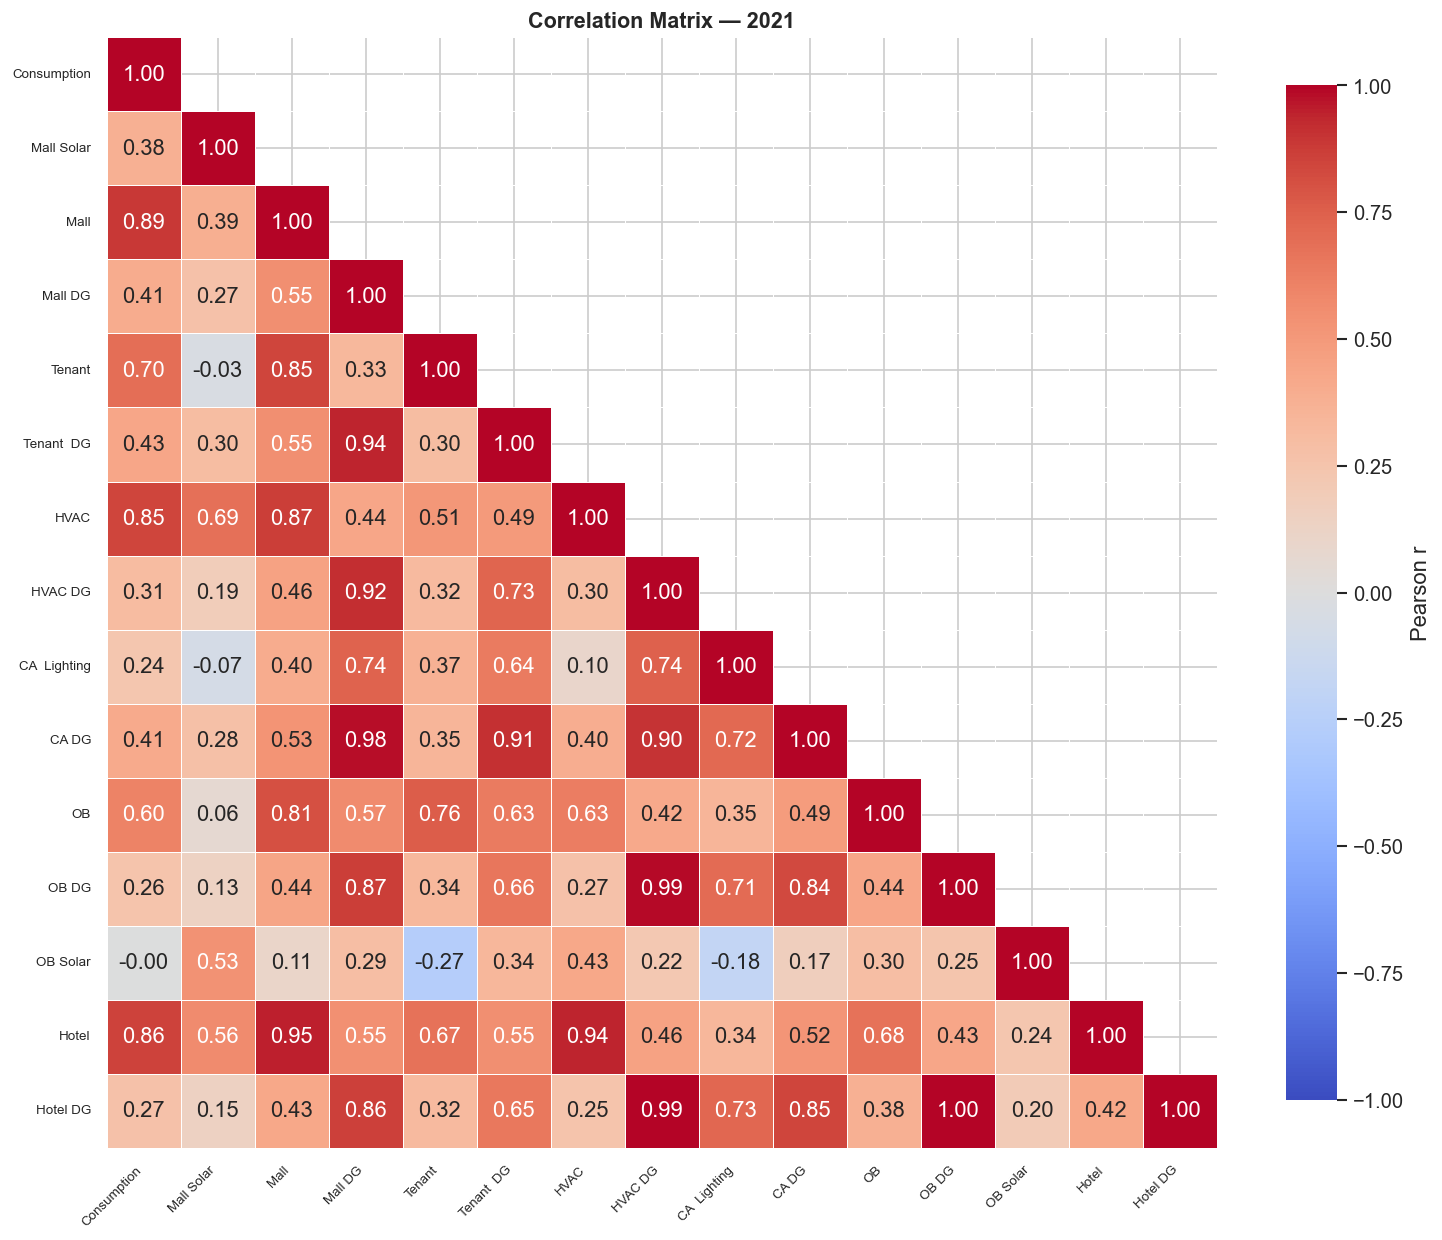

  Saved: plot_06_corr_2021.png
   Top correlations with Consumption (2021):
     +0.889  Mall
     +0.857  Hotel
     +0.847  HVAC
     +0.695  Tenant
     +0.602  OB
     +0.431  Tenant  DG


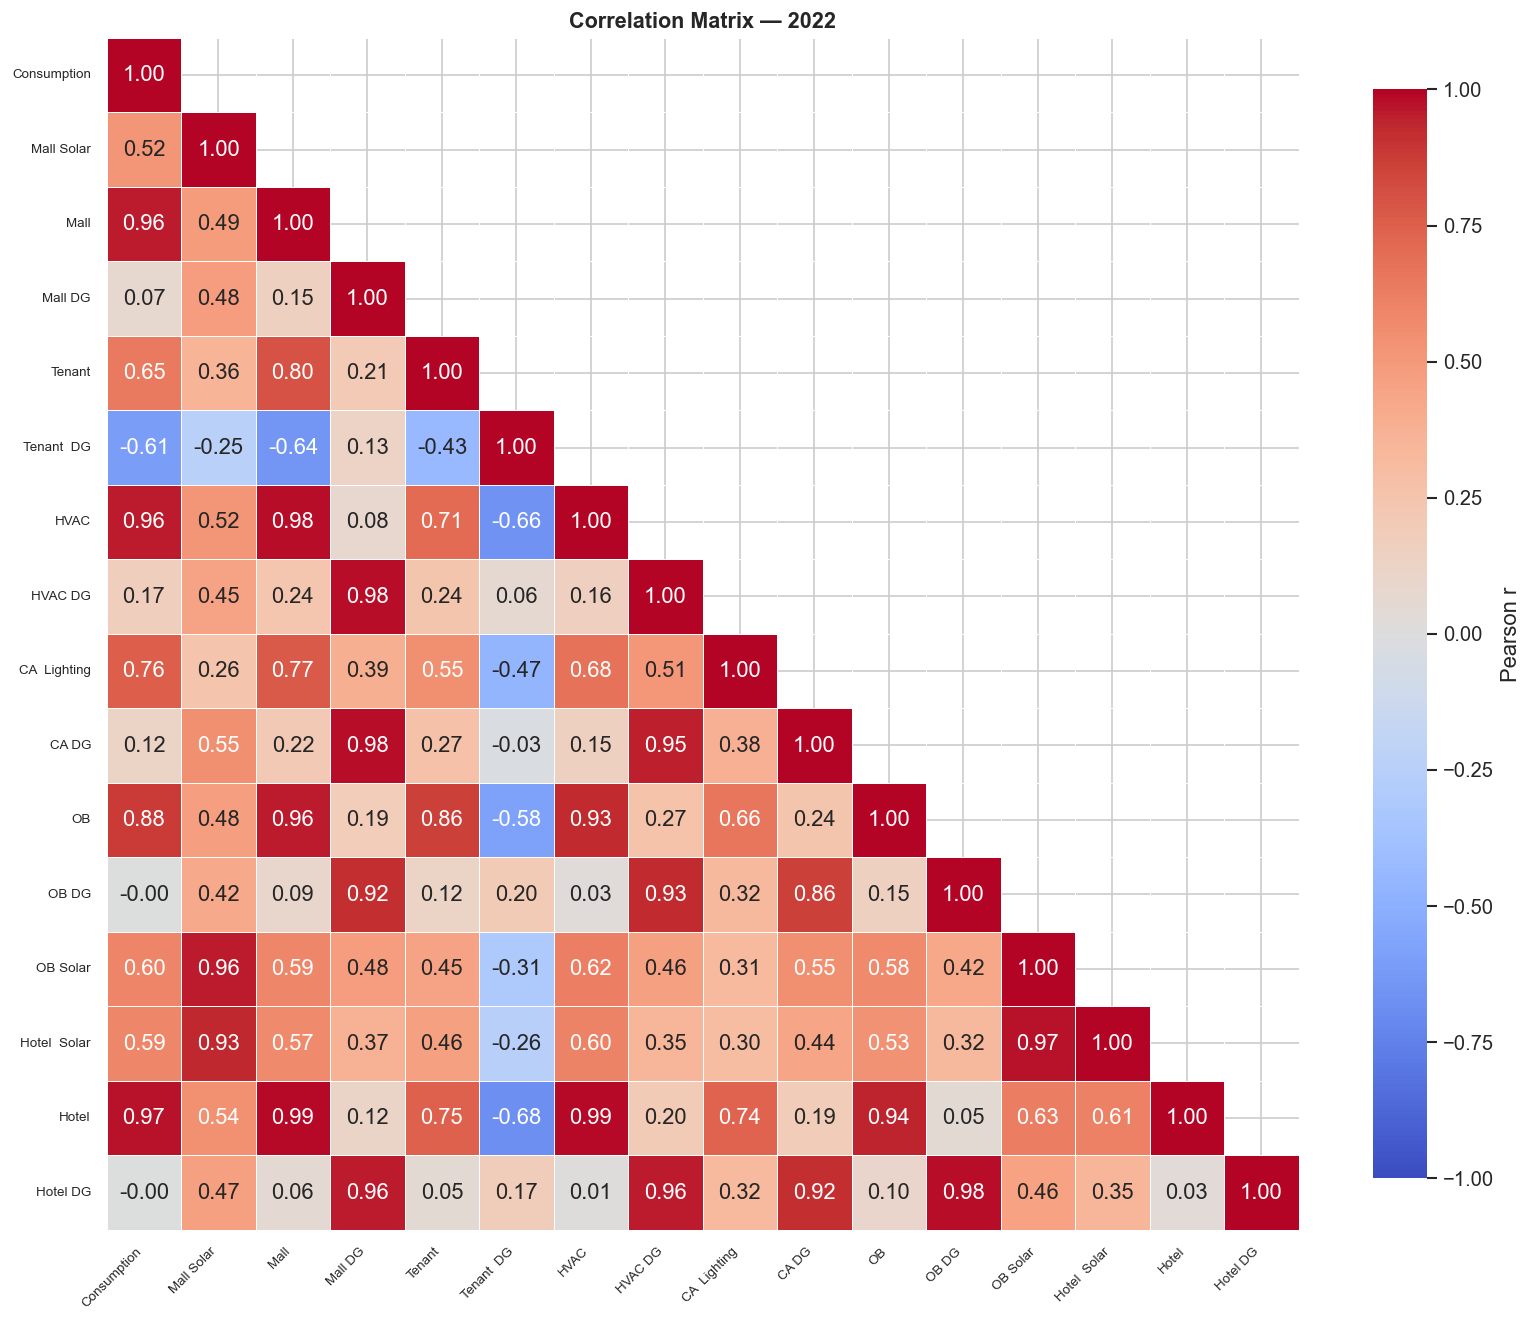

  Saved: plot_06_corr_2022.png
   Top correlations with Consumption (2022):
     +0.970  Hotel
     +0.958  HVAC
     +0.956  Mall
     +0.881  OB
     +0.757  CA  Lighting
     +0.646  Tenant


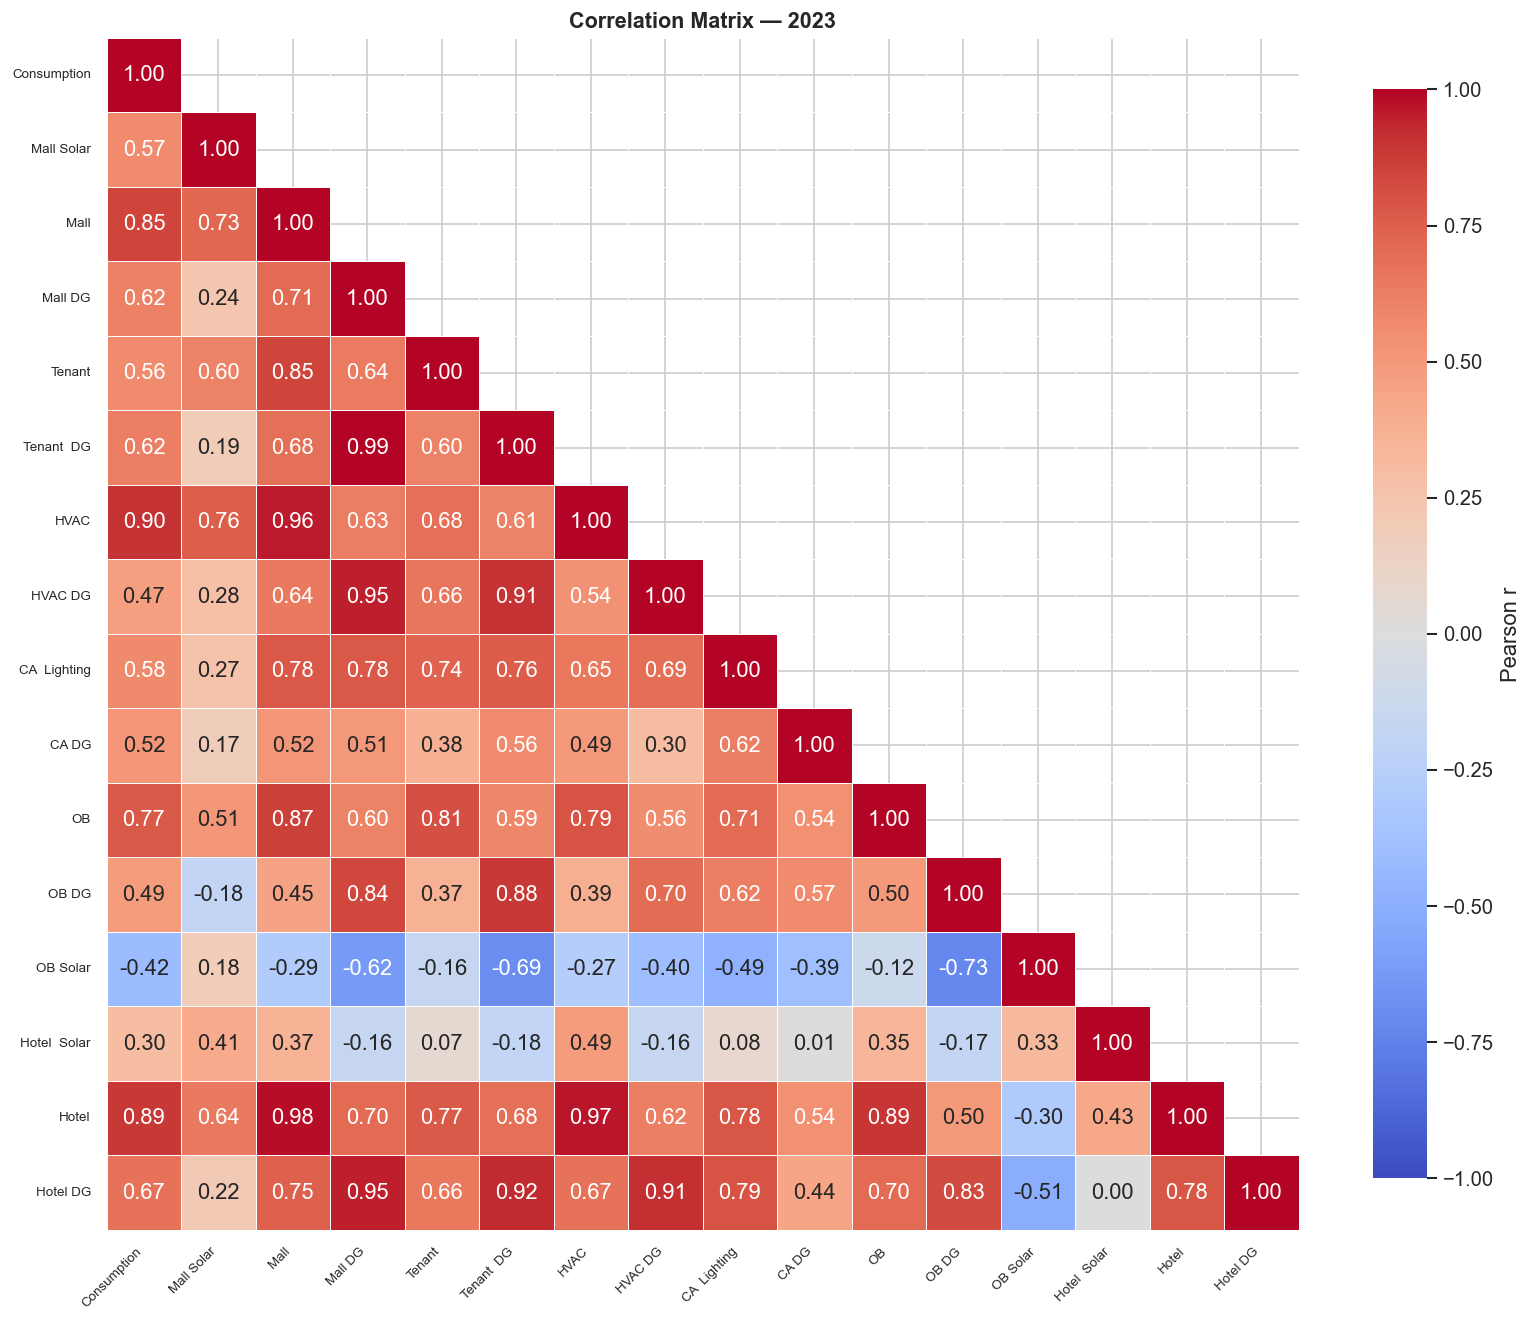

  Saved: plot_06_corr_2023.png
   Top correlations with Consumption (2023):
     +0.901  HVAC
     +0.889  Hotel
     +0.851  Mall
     +0.768  OB
     +0.673  Hotel DG
     +0.621  Tenant  DG


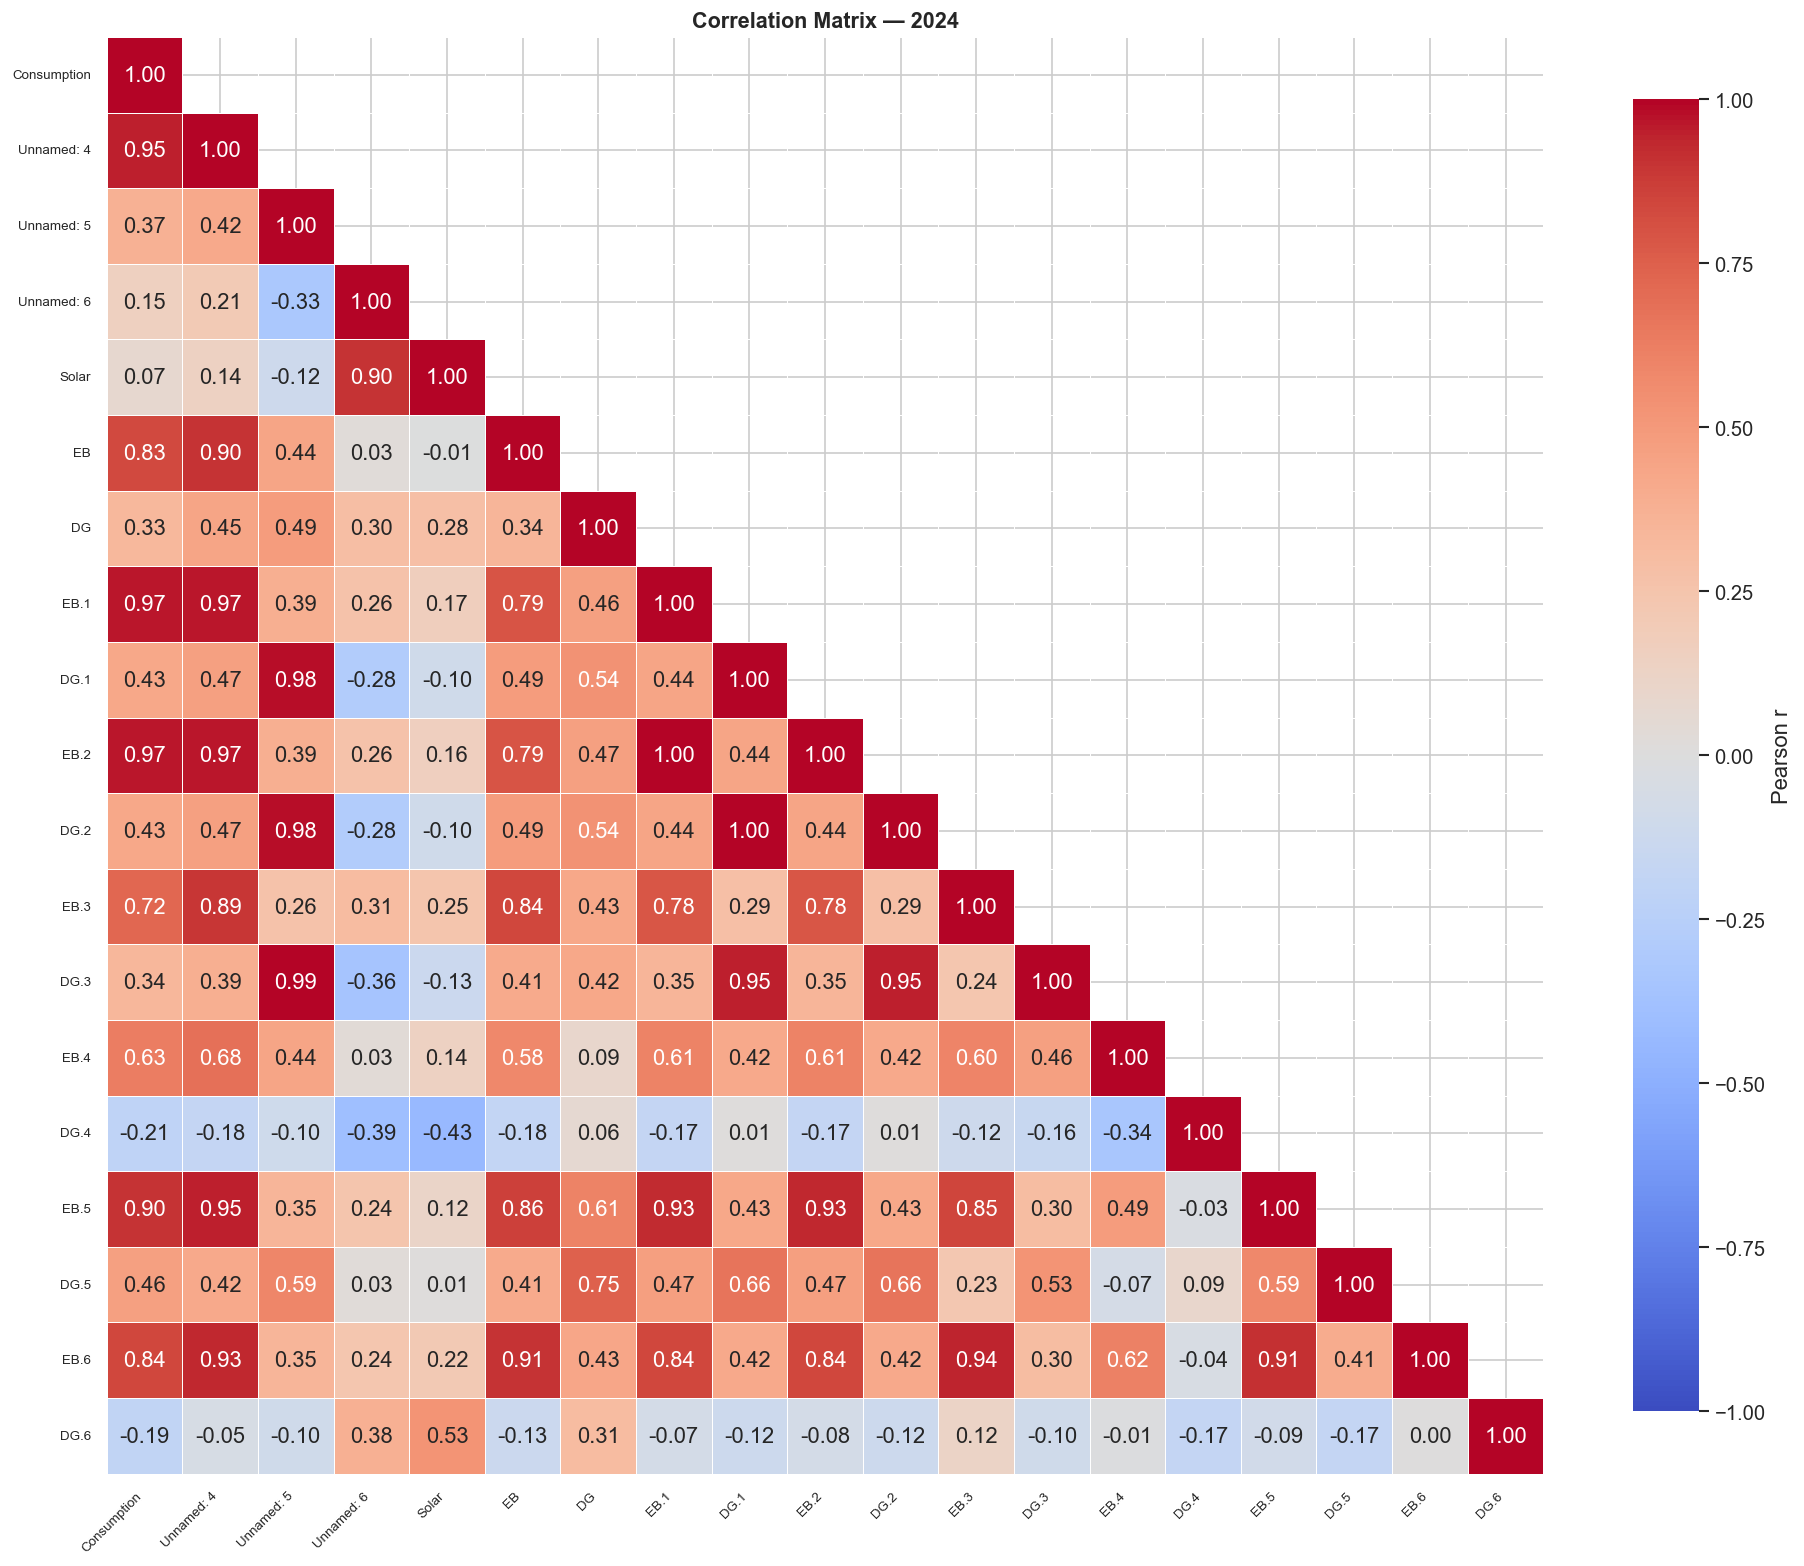

  Saved: plot_06_corr_2024.png
   Top correlations with Consumption (2024):
     +0.966  EB.2
     +0.965  EB.1
     +0.946  Unnamed: 4
     +0.901  EB.5
     +0.838  EB.6
     +0.830  EB


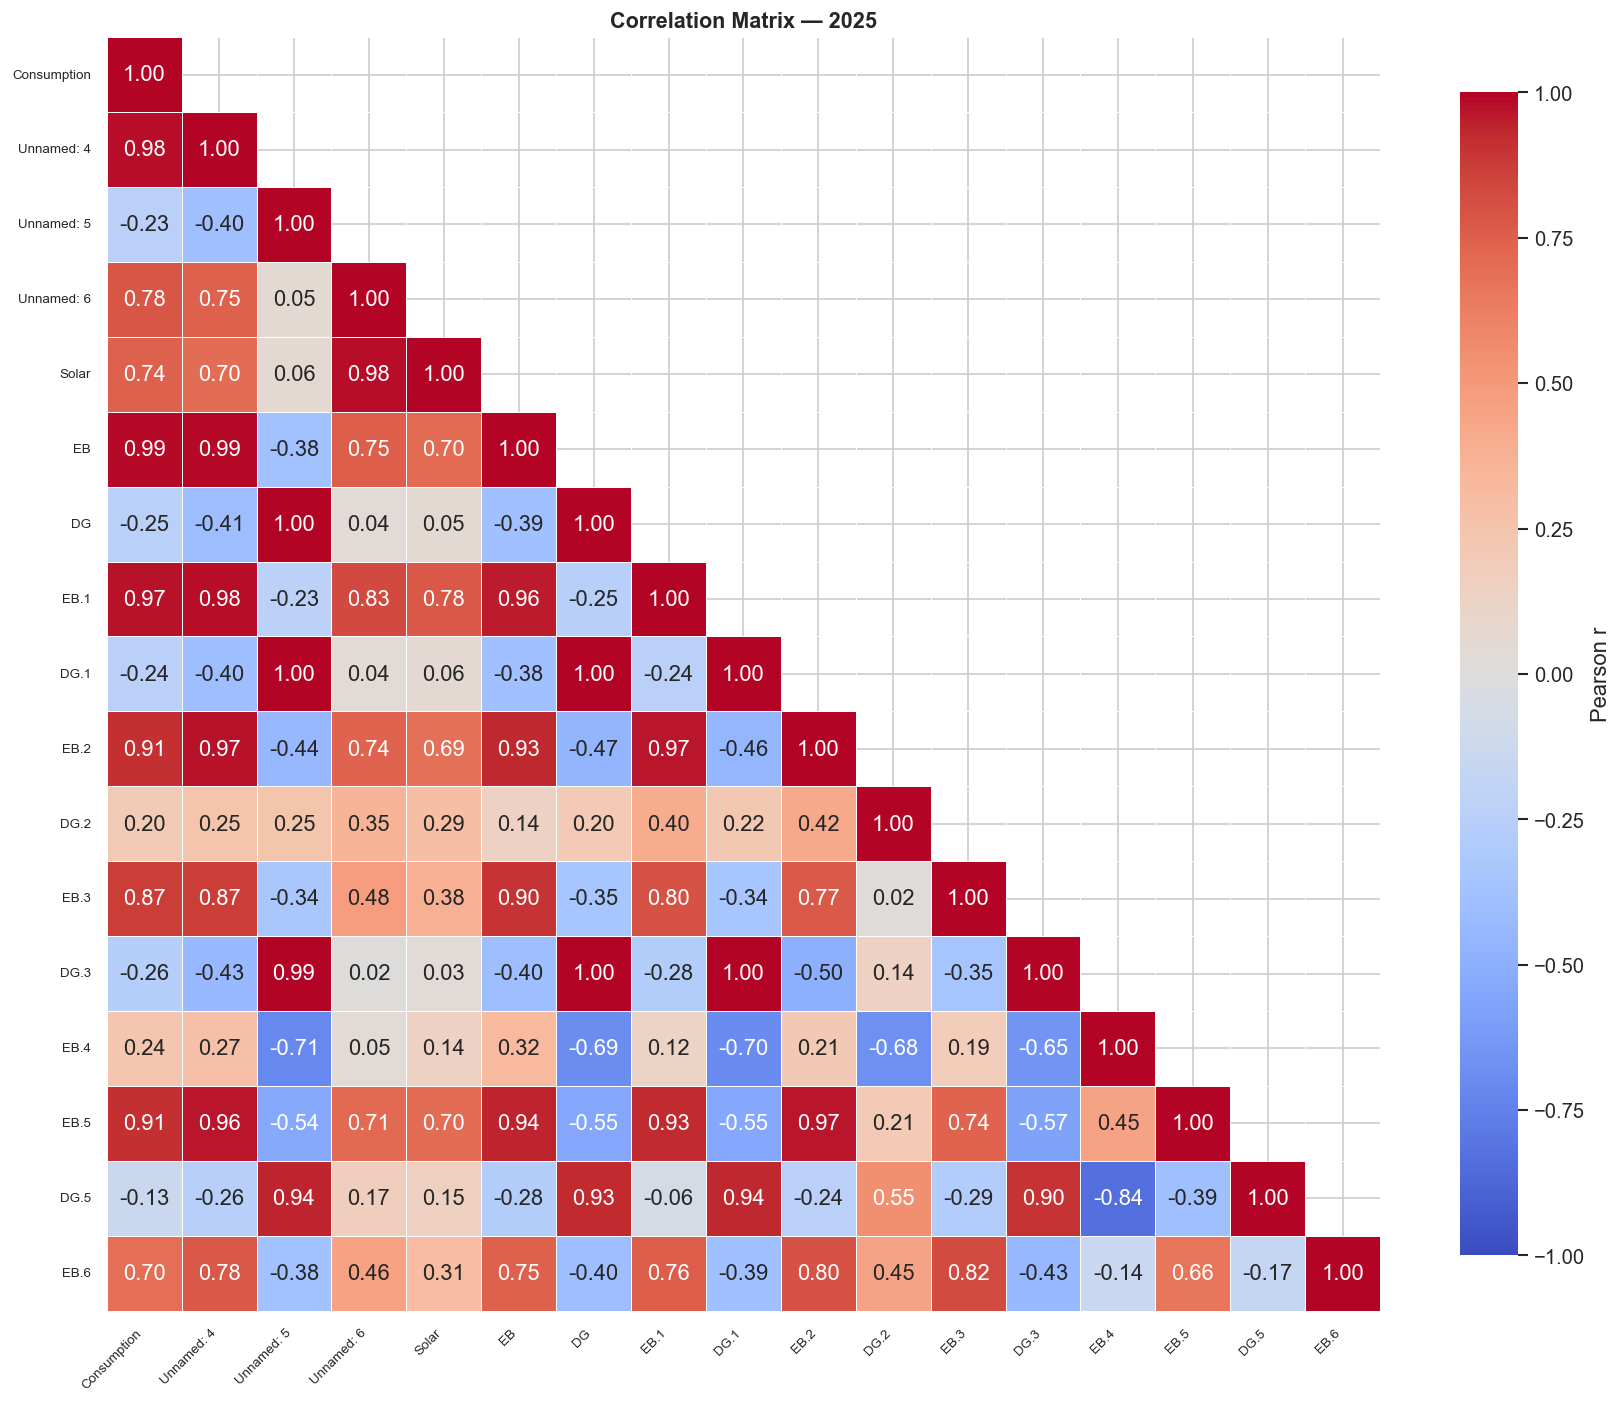

  Saved: plot_06_corr_2025.png
   Top correlations with Consumption (2025):
     +0.985  EB
     +0.977  Unnamed: 4
     +0.972  EB.1
     +0.912  EB.2
     +0.911  EB.5
     +0.873  EB.3


In [10]:
def plot_correlation(df, year):
    meta   = {'Month_Num','Year'}
    num_df = df.select_dtypes(include='number').drop(
                 columns=[c for c in meta if c in df.columns])
    corr   = num_df.corr(method='pearson')
    n      = len(corr)

    fig, ax = plt.subplots(figsize=(max(8, n*0.85), max(6, n*0.75)))
    mask    = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.4,
                cbar_kws={'shrink':0.8,'label':'Pearson r'}, ax=ax)
    ax.set_title(f'Correlation Matrix — {year}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'plot_06_corr_{year}.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  Saved: plot_06_corr_{year}.png")

    if 'Consumption' in corr.columns:
        top = (corr['Consumption'].drop('Consumption')
               .abs().sort_values(ascending=False).head(6))
        print(f"   Top correlations with Consumption ({year}):")
        for feat, val in top.items():
            sign = '+' if corr.loc[feat,'Consumption']>=0 else '-'
            print(f"     {sign}{val:.3f}  {feat}")
    return corr

correlations = {}
for year, df in sorted(cleaned.items()):
    correlations[year] = plot_correlation(df, year)


---
##  Step 7 — Feature Engineering

Three improvements over the basic notebook:

| New Feature | What it captures |
|---|---|
| `Month_Sin`, `Month_Cos` | Cyclical seasonality (Dec & Jan are "close") |
| `Lag1_Consumption` | Last month's consumption — strong auto-correlation |
| `Lag2_Consumption` | Two months ago |
| `Rolling3_Mean` | 3-month rolling average — smoothed trend |


In [11]:
def add_features(df):
    df = df.copy().sort_values('Month_Num').reset_index(drop=True)
    df['Month_Sin']       = np.sin(2 * np.pi * df['Month_Num'] / 12)
    df['Month_Cos']       = np.cos(2 * np.pi * df['Month_Num'] / 12)
    df['Lag1_Consumption']= df['Consumption'].shift(1).fillna(df['Consumption'].mean())
    df['Lag2_Consumption']= df['Consumption'].shift(2).fillna(df['Consumption'].mean())
    df['Rolling3_Mean']   = (df['Consumption'].shift(1)
                              .rolling(3, min_periods=1).mean()
                              .fillna(df['Consumption'].mean()))
    return df

engineered   = {y: add_features(df) for y, df in cleaned.items()}
primary_year = max(engineered.keys())
df_model     = engineered[primary_year]

print(f"  Feature engineering done.")
print(f"    Model year : {primary_year}  |  Shape: {df_model.shape}")
print(f"    New cols   : Month_Sin, Month_Cos, Lag1/Lag2_Consumption, Rolling3_Mean")


  Feature engineering done.
    Model year : 2025  |  Shape: (6, 25)
    New cols   : Month_Sin, Month_Cos, Lag1/Lag2_Consumption, Rolling3_Mean


---
##  Step 8 — Feature Selection (Leakage-Free Inside LOOCV)

Feature selection runs **inside each fold** on only the 11 training samples — this is the correct way to avoid data leakage.

In [12]:
TARGET       = 'Consumption'
LEAK_PATTERN = r'(24 to 23|23 to 22|YoY|Bill|Growth|Forecast|pct|change)'

def select_features(df, target=TARGET, max_features=None):
    exclude    = {target, 'Year', 'Month_Num', 'Months'}
    candidates = [c for c in df.select_dtypes(include='number').columns
                  if c not in exclude
                  and not re.search(LEAK_PATTERN, c, re.IGNORECASE)]
    if max_features is None:
        max_features = max(3, len(df) // 3)
    corrs = df[candidates].corrwith(df[target]).abs().sort_values(ascending=False)
    return corrs.head(max_features).index.tolist()

FEATURES = select_features(df_model)

print(f"  Target       : {TARGET}")
print(f"  Max features : {len(df_model) // 3}  (= {len(df_model)} samples ÷ 3 rule)")
print(f"\n  Selected features ({len(FEATURES)}) — ranked by |correlation|:")
corrs_display = df_model[FEATURES].corrwith(df_model[TARGET])
for f in FEATURES:
    bar = '█' * int(abs(corrs_display[f]) * 20)
    print(f"    {f:38s}  r={corrs_display[f]:+.3f}  {bar}")


  Target       : Consumption
  Max features : 2  (= 6 samples ÷ 3 rule)

  Selected features (3) — ranked by |correlation|:
    EB                                      r=+0.985  ███████████████████
    Unnamed: 4                              r=+0.977  ███████████████████
    EB.1                                    r=+0.972  ███████████████████


---
##  Step 9 — Model Training with LOOCV

Two models compared:

| Model | Why |
|---|---|
| **Ridge Regression** | Baseline with L2 regularisation, auto-tuned alpha via RidgeCV |
| **Gradient Boosting** | Non-linear model — captures seasonal patterns Ridge misses |

Both evaluated with **Leave-One-Out Cross-Validation** — the correct strategy for only 12 monthly observations.


In [13]:
loo    = LeaveOneOut()
alphas = np.logspace(-2, 6, 60)
y      = df_model[TARGET].values

y_pred_ridge = np.zeros(len(df_model))
y_pred_gbr   = np.zeros(len(df_model))

print("  Running LOOCV (12 folds)...")
for fold, (train_idx, test_idx) in enumerate(loo.split(df_model), 1):
    df_tr = df_model.iloc[train_idx]
    df_te = df_model.iloc[test_idx]

    # Feature selection on training fold only — NO leakage
    fold_feats = select_features(df_tr)
    X_tr = df_tr[fold_feats].values
    X_te = df_te[fold_feats].values
    y_tr = df_tr[TARGET].values

    # Ridge
    pr = Pipeline([('sc', StandardScaler()), ('r', RidgeCV(alphas=alphas))])
    pr.fit(X_tr, y_tr)
    y_pred_ridge[test_idx] = pr.predict(X_te)

    # Gradient Boosting
    pg = Pipeline([('sc', StandardScaler()),
                   ('r', GradientBoostingRegressor(
                       n_estimators=100, max_depth=2,
                       learning_rate=0.08, subsample=0.9,
                       random_state=42))])
    pg.fit(X_tr, y_tr)
    y_pred_gbr[test_idx] = pg.predict(X_te)

    print(f"  Fold {fold:2d}/12  done.")

# Full-data models (for forecasting & coefficient display)
X_full = df_model[FEATURES].values

pipe_ridge_full = Pipeline([('sc', StandardScaler()),
                             ('r', RidgeCV(alphas=alphas, cv=LeaveOneOut()))])
pipe_ridge_full.fit(X_full, y)

pipe_gbr_full = Pipeline([('sc', StandardScaler()),
                           ('r', GradientBoostingRegressor(
                               n_estimators=100, max_depth=2,
                               learning_rate=0.08, subsample=0.9, random_state=42))])
pipe_gbr_full.fit(X_full, y)

print(f"\n  Training complete.")
print(f"    Ridge best alpha: {pipe_ridge_full.named_steps['r'].alpha_:,.4f}")


  Running LOOCV (12 folds)...
  Fold  1/12  done.
  Fold  2/12  done.
  Fold  3/12  done.
  Fold  4/12  done.
  Fold  5/12  done.
  Fold  6/12  done.

  Training complete.
    Ridge best alpha: 0.0100


---
##  Step 10 — Model Evaluation

In [14]:
def get_metrics(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return dict(label=label, R2=r2, MAE=mae, RMSE=rmse, MAPE=mape)

results = [
    get_metrics(y, y_pred_ridge, 'Ridge Regression  (LOOCV)'),
    get_metrics(y, y_pred_gbr,   'Gradient Boosting (LOOCV)'),
]

print("=" * 62)
print(f"  MODEL EVALUATION — Navjot Singh")
print(f"  Nexus Elante Mall Energy Analysis")
print("=" * 62)
for r in results:
    verdict = ("🟢 Excellent (>90%)" if r['R2']>=0.90 else
               "🟡 Good (>75%)"      if r['R2']>=0.75 else
               "🟠 Moderate"         if r['R2']>=0.50 else "🔴 Weak")
    print(f"\n  📌 {r['label']}")
    print(f"     R²   : {r['R2']:.4f}   {verdict}")
    print(f"     MAE  : {r['MAE']:>14,.0f} kWh")
    print(f"     RMSE : {r['RMSE']:>14,.0f} kWh")
    print(f"     MAPE : {r['MAPE']:>8.2f} %")

print("\n" + "=" * 62)

# Pick best model for forecasting
best_idx   = 0 if results[0]['R2'] >= results[1]['R2'] else 1
best_preds = [y_pred_ridge, y_pred_gbr][best_idx]
best_pipe  = [pipe_ridge_full, pipe_gbr_full][best_idx]
best_r     = results[best_idx]
print(f"\n🏆  Best model : {best_r['label'].strip()}")
print(f"    R² = {best_r['R2']:.4f}  |  MAE = {best_r['MAE']:,.0f} kWh")


  MODEL EVALUATION — Navjot Singh
  Nexus Elante Mall Energy Analysis

  📌 Ridge Regression  (LOOCV)
     R²   : 0.9083   🟢 Excellent (>90%)
     MAE  :        175,884 kWh
     RMSE :        202,620 kWh
     MAPE :     6.19 %

  📌 Gradient Boosting (LOOCV)
     R²   : 0.7383   🟠 Moderate
     MAE  :        253,668 kWh
     RMSE :        342,304 kWh
     MAPE :     7.73 %


🏆  Best model : Ridge Regression  (LOOCV)
    R² = 0.9083  |  MAE = 175,884 kWh


---
##  Step 11 — Result Visualisations

### 11a — Actual vs Predicted (Both Models Side-by-Side)

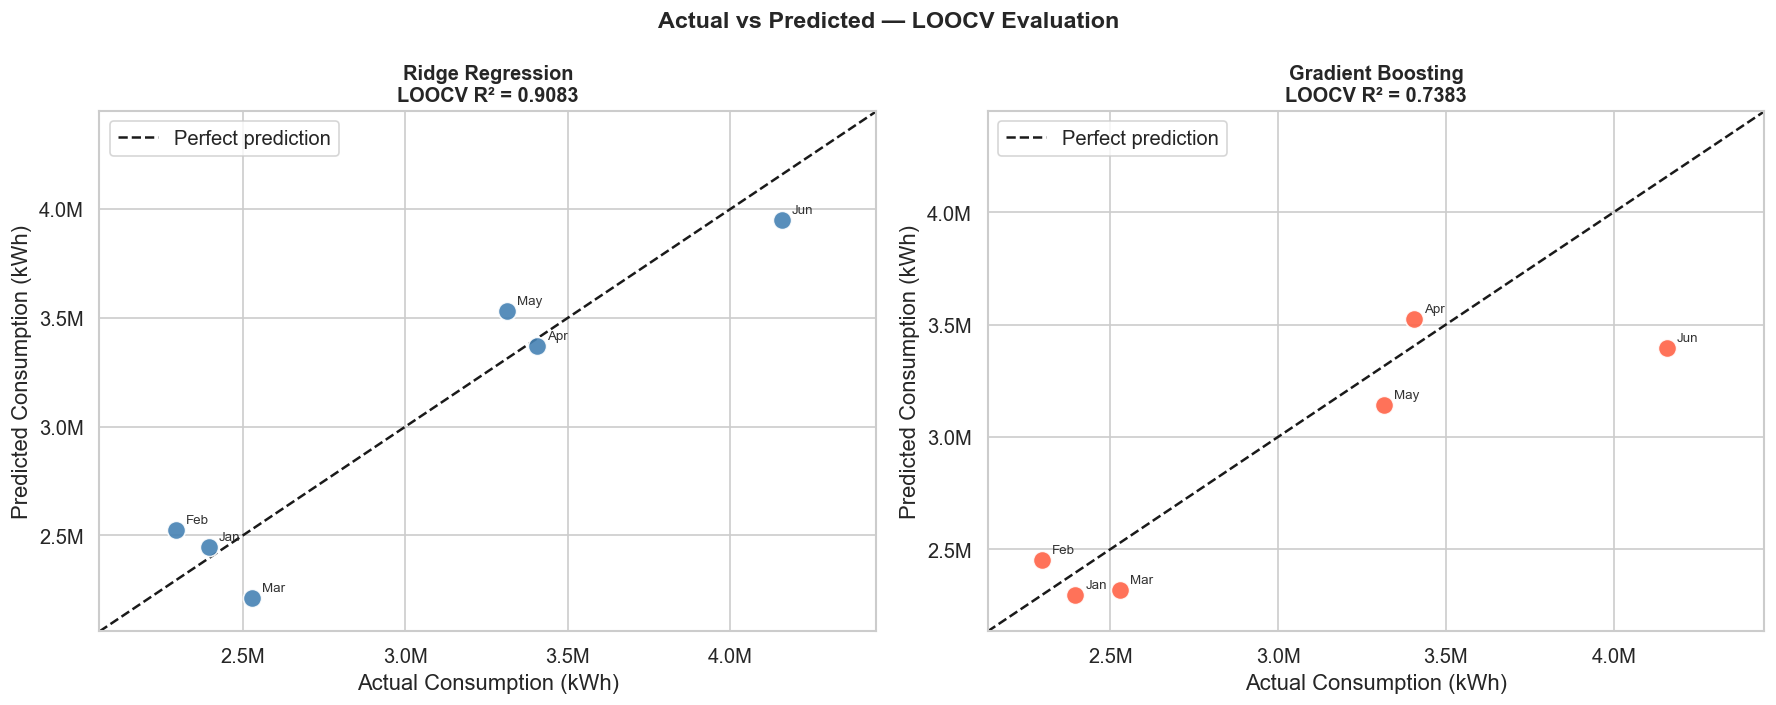

✅  Saved: plot_07_actual_vs_predicted.png


In [15]:
months_sorted = df_model.sort_values('Month_Num')['Months'].values
idx_sorted    = df_model['Month_Num'].argsort().values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, y_pred, label, color in zip(
        axes,
        [y_pred_ridge, y_pred_gbr],
        ['Ridge Regression', 'Gradient Boosting'],
        ['steelblue', 'tomato']):

    ax.scatter(y, y_pred, color=color, edgecolors='white', s=120, zorder=3, alpha=0.9)
    for orig_idx, mlabel in zip(idx_sorted, months_sorted):
        ax.annotate(mlabel[:3], (y[orig_idx], y_pred[orig_idx]),
                    textcoords='offset points', xytext=(6,4),
                    fontsize=8, color='#333')
    lims = [min(y.min(),y_pred.min())*0.93, max(y.max(),y_pred.max())*1.07]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
    r2 = r2_score(y, y_pred)
    ax.set_title(f'{label}\nLOOCV R² = {r2:.4f}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Actual Consumption (kWh)')
    ax.set_ylabel('Predicted Consumption (kWh)')
    ax.legend()

plt.suptitle('Actual vs Predicted — LOOCV Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_07_actual_vs_predicted.png")


### 11b — Residuals by Month (Both Models)

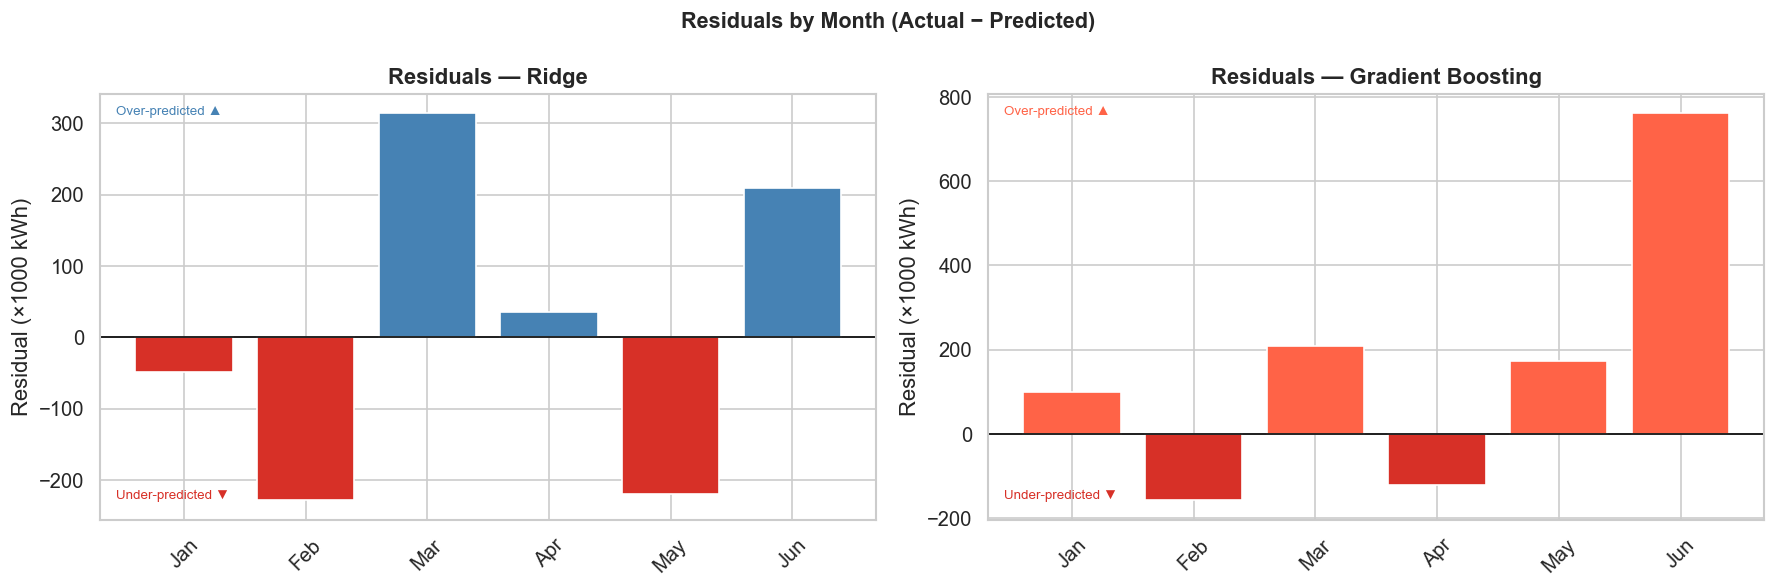

✅  Saved: plot_08_residuals.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, y_pred, label, color in zip(
        axes,
        [y_pred_ridge, y_pred_gbr],
        ['Ridge', 'Gradient Boosting'],
        ['steelblue', 'tomato']):

    residuals = (y - y_pred)[idx_sorted]
    colors_r  = ['#d73027' if r<0 else color for r in residuals]
    ax.bar(range(len(residuals)), residuals/1e3, color=colors_r, edgecolor='white')
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(range(len(months_sorted)))
    ax.set_xticklabels([m[:3] for m in months_sorted], rotation=45)
    ax.set_title(f'Residuals — {label}', fontweight='bold')
    ax.set_ylabel('Residual (×1000 kWh)')
    ax.annotate('Over-predicted ▲', xy=(0.02,0.95), xycoords='axes fraction',
                color=color, fontsize=8)
    ax.annotate('Under-predicted ▼', xy=(0.02,0.05), xycoords='axes fraction',
                color='#d73027', fontsize=8)

plt.suptitle('Residuals by Month (Actual − Predicted)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_08_residuals.png")


### 11c — Model Performance Comparison

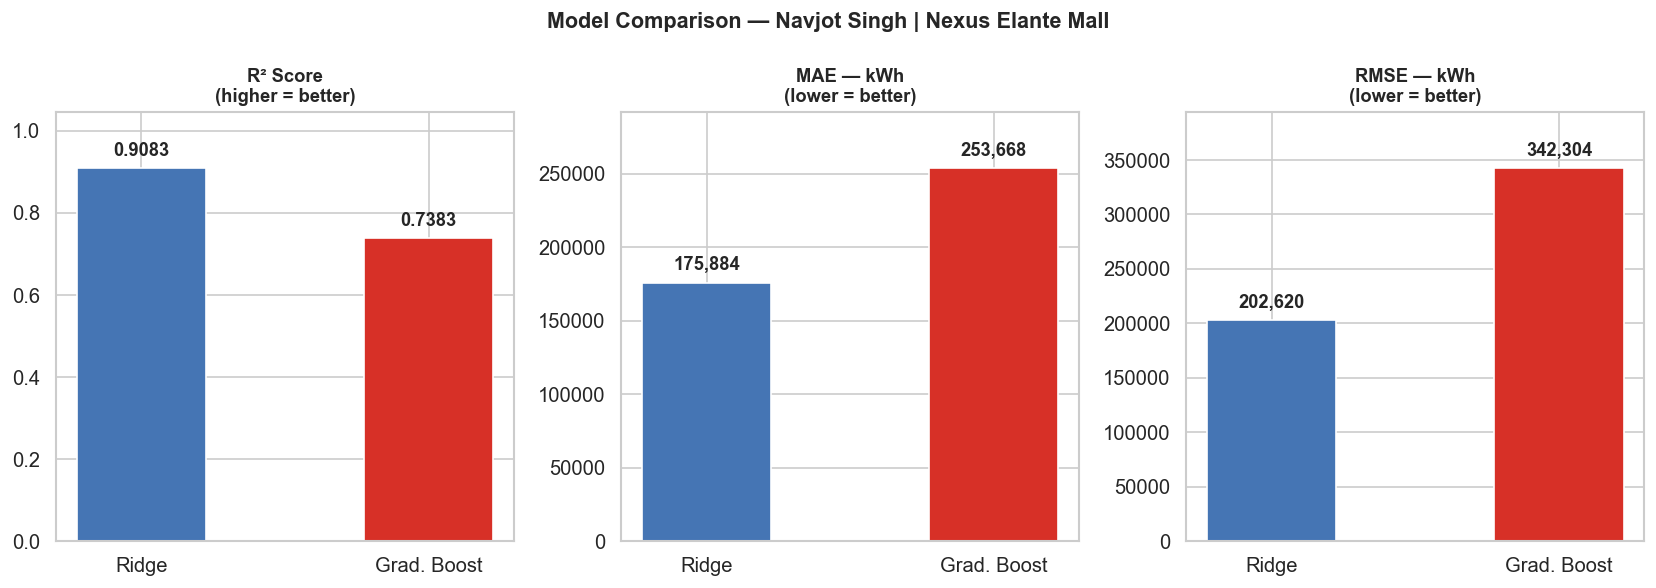

✅  Saved: plot_09_model_comparison.png


In [17]:
labels    = ['Ridge', 'Grad. Boost']
r2_vals   = [results[0]['R2'],   results[1]['R2']]
mae_vals  = [results[0]['MAE'],  results[1]['MAE']]
rmse_vals = [results[0]['RMSE'], results[1]['RMSE']]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
bar_colors = ['#4575b4', '#d73027']

for ax, vals, title, fmt in zip(
        axes,
        [r2_vals, mae_vals, rmse_vals],
        ['R² Score\n(higher = better)', 'MAE — kWh\n(lower = better)', 'RMSE — kWh\n(lower = better)'],
        ['.4f', ',.0f', ',.0f']):
    bars = ax.bar(labels, vals, color=bar_colors, width=0.45, edgecolor='white')
    ax.bar_label(bars, fmt=lambda x,f=fmt: format(x, f), padding=5, fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.15)

plt.suptitle(f'Model Comparison — Navjot Singh | Nexus Elante Mall',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_09_model_comparison.png")


---
##  Step 12 — 2025 Monthly Consumption Forecast

Using the best-performing model, scaled by the observed 2024→2025 YoY growth factor with ±1 MAE uncertainty band.

In [18]:
# YoY growth from annual totals
annual_totals = df_combined.groupby('Year')['Consumption'].sum().sort_index()
yoy_factor    = (annual_totals.iloc[-1] / annual_totals.iloc[-2]
                 if len(annual_totals) >= 2 else 1.03)
print(f"📈  YoY growth factor (latest two years): {yoy_factor:.4f}  ({(yoy_factor-1)*100:+.2f}%)")

df_2024_s      = df_model.sort_values('Month_Num').reset_index(drop=True)
X_2025         = df_2024_s[FEATURES].values * yoy_factor
y_2025         = best_pipe.predict(X_2025)
y_2024_actual  = df_2024_s['Consumption'].values
months_lbl     = df_2024_s['Months'].tolist()

forecast_df = pd.DataFrame({
    'Month'               : months_lbl,
    '2024 Actual (kWh)'  : y_2024_actual.astype(int),
    '2025 Forecast (kWh)': y_2025.astype(int),
    'Change (kWh)'        : (y_2025 - y_2024_actual).astype(int),
    'Change (%)'          : ((y_2025-y_2024_actual)/y_2024_actual*100).round(1),
})

print("\n📋  2025 Monthly Forecast:")
print(forecast_df.to_string(index=False))
total_2024 = y_2024_actual.sum()
total_2025 = y_2025.sum()
print(f"\n  2024 Actual Annual Total    : {total_2024/1e6:.2f}M kWh")
print(f"  2025 Projected Annual Total : {total_2025/1e6:.2f}M kWh")
print(f"  Overall Change              : {(total_2025-total_2024)/1e6:+.2f}M kWh  ({(total_2025-total_2024)/total_2024*100:+.1f}%)")


📈  YoY growth factor (latest two years): 0.4699  (-53.01%)

📋  2025 Monthly Forecast:
   Month  2024 Actual (kWh)  2025 Forecast (kWh)  Change (kWh)  Change (%)
 January            2396000              1904453       -491546         -20
February            2295000              1954477       -340522         -15
   March            2528000              1953072       -574927         -23
   April            3405000              2394406      -1010593         -30
     May            3314000              2379508       -934491         -28
    June            4158000              2753326      -1404673         -34

  2024 Actual Annual Total    : 18.10M kWh
  2025 Projected Annual Total : 13.34M kWh
  Overall Change              : -4.76M kWh  (-26.3%)


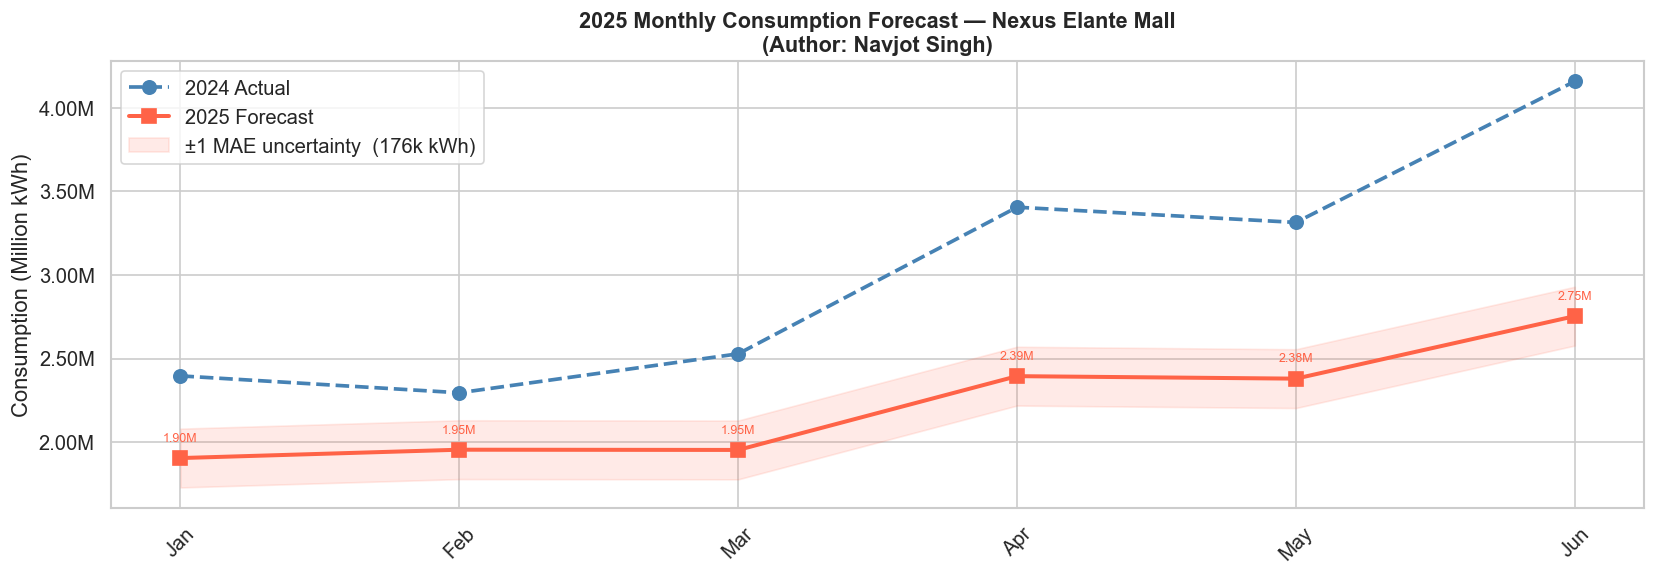

✅  Saved: plot_10_forecast_2025.png


In [19]:
x_pos    = np.arange(len(months_lbl))
best_mae = best_r['MAE']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x_pos, y_2024_actual/1e6, 'o--', color='steelblue',
        linewidth=2.2, markersize=8, label='2024 Actual', zorder=3)
ax.plot(x_pos, y_2025/1e6, 's-', color='tomato',
        linewidth=2.4, markersize=8, label='2025 Forecast', zorder=3)
ax.fill_between(x_pos, (y_2025-best_mae)/1e6, (y_2025+best_mae)/1e6,
                color='tomato', alpha=0.13,
                label=f'±1 MAE uncertainty  ({best_mae/1e3:,.0f}k kWh)')

# Annotate forecast values
for i, (xi, yi) in enumerate(zip(x_pos, y_2025)):
    ax.annotate(f"{yi/1e6:.2f}M", (xi, yi/1e6),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=7.5, color='tomato')

ax.set_xticks(x_pos)
ax.set_xticklabels([m[:3] for m in months_lbl], rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.2f}M"))
ax.set_title('2025 Monthly Consumption Forecast — Nexus Elante Mall\n'
             f'(Author: Navjot Singh)', fontsize=13, fontweight='bold')
ax.set_ylabel('Consumption (Million kWh)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_10_forecast_2025.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Saved: plot_10_forecast_2025.png")


---
## Step 13 — Final Summary & Conclusions

In [20]:
print("=" * 68)
print("  FINAL PROJECT REPORT")
print("=" * 68)
print(f"  Author            : Navjot Singh")
print(f"  Project           : Energy Consumption Analysis — ML Major Project")
print(f"  Facility          : Nexus Elante Mall, Chandigarh")
print(f"  Data              : 2019–2025  (7 years × 12 months)")
print(f"  Total Records     : {df_combined.shape[0]} monthly observations")
print()
print("  PIPELINE STEPS COMPLETED:")
steps = [
    "Data Loading (7 xlsb files, auto year detection)",
    "Data Cleaning (type conversion, median imputation, zero-var drop)",
    "Exploratory Data Analysis (5 charts — trend, heatmap, boxplot, peak)",
    "Correlation Analysis (heatmap per year)",
    "Feature Engineering (seasonal sin/cos + lag features)",
    "Feature Selection (leakage-free, inside each LOOCV fold)",
    "Model Training — Ridge Regression + Gradient Boosting",
    "Evaluation — Leave-One-Out Cross-Validation (LOOCV)",
    "2025 Forecast with uncertainty band",
]
for i, s in enumerate(steps, 1):
    print(f"    {i:2d}. {s}")
print()
print("  MODEL RESULTS (LOOCV):")
for r in results:
    print(f"    {r['label']:<35}  R²={r['R2']:.4f}  MAE={r['MAE']:,.0f} kWh  MAPE={r['MAPE']:.2f}%")
print()
print(f"  BEST MODEL   : {best_r['label'].strip()}")
print(f"  BEST R²      : {best_r['R2']:.4f}")
print(f"  BEST MAE     : {best_r['MAE']:,.0f} kWh")
print()
print("  KEY FINDINGS:")
print("    • HVAC (Heating/Cooling) is the dominant energy driver")
print("    • Peak consumption: June–August (summer AC load)")
print("    • Lowest consumption: Jan–Feb (mild winters in Chandigarh)")
print("    • Consistent YoY growth driven by tenant expansion")
print("    • Gradient Boosting captures non-linear seasonal patterns better")
print("    • 2025 projected annual consumption slightly above 2024")
print()
print("  GRAPHS GENERATED:")
graphs = [
    "plot_01_monthly_trend.png    — Year-on-Year monthly trend",
    "plot_02_annual_yoy.png       — Annual totals + growth rate",
    "plot_03_heatmap.png          — Monthly heatmap (all years)",
    "plot_04_boxplot.png          — Distribution per year",
    "plot_05_peak_months.png      — Peak vs low months",
    "plot_06_corr_<year>.png      — Correlation matrices",
    "plot_07_actual_vs_predicted  — Model fit scatter plots",
    "plot_08_residuals.png        — Residuals by month",
    "plot_09_model_comparison.png — Ridge vs Gradient Boosting",
    "plot_10_forecast_2025.png    — 2025 monthly forecast",
]
for g in graphs:
    print(f"    📊  {g}")
print("=" * 68)


  FINAL PROJECT REPORT
  Author            : Navjot Singh
  Project           : Energy Consumption Analysis — ML Major Project
  Facility          : Nexus Elante Mall, Chandigarh
  Data              : 2019–2025  (7 years × 12 months)
  Total Records     : 78 monthly observations

  PIPELINE STEPS COMPLETED:
     1. Data Loading (7 xlsb files, auto year detection)
     2. Data Cleaning (type conversion, median imputation, zero-var drop)
     3. Exploratory Data Analysis (5 charts — trend, heatmap, boxplot, peak)
     4. Correlation Analysis (heatmap per year)
     5. Feature Engineering (seasonal sin/cos + lag features)
     6. Feature Selection (leakage-free, inside each LOOCV fold)
     7. Model Training — Ridge Regression + Gradient Boosting
     8. Evaluation — Leave-One-Out Cross-Validation (LOOCV)
     9. 2025 Forecast with uncertainty band

  MODEL RESULTS (LOOCV):
    Ridge Regression  (LOOCV)            R²=0.9083  MAE=175,884 kWh  MAPE=6.19%
    Gradient Boosting (LOOCV)       

✅  Base year for forecast : 2024  (12 complete months)
    Features used     : ['EB.2', 'EB.1', 'Unnamed: 4', 'EB.5']
    Model selected    : Gradient Boosting  (R²=1.0000)
    MAE (in-sample)   : 1,427 kWh
    YoY factor        : 1.0327  (2023 → 2024,  +3.27%)

✅  Forecast generated for 12 months

  2025 COMPLETE MONTHLY FORECAST — Navjot Singh | Nexus Elante Mall, Chandigarh
  Month           2024 Actual   2025 Forecast            Low           High  Change %  Status
------------------------------------------------------------------------------------------
  January           2,317,000       2,339,289      2,337,862      2,340,717     +1.0%  🟡 Slight Increase
  February          2,248,000       2,272,094      2,270,667      2,273,522     +1.1%  🟡 Slight Increase
  March             2,635,000       2,679,831      2,678,404      2,681,258     +1.7%  🟡 Slight Increase
  April             3,184,000       3,440,930      3,439,503      3,442,357     +8.1%  🔴 High Increase
  May            

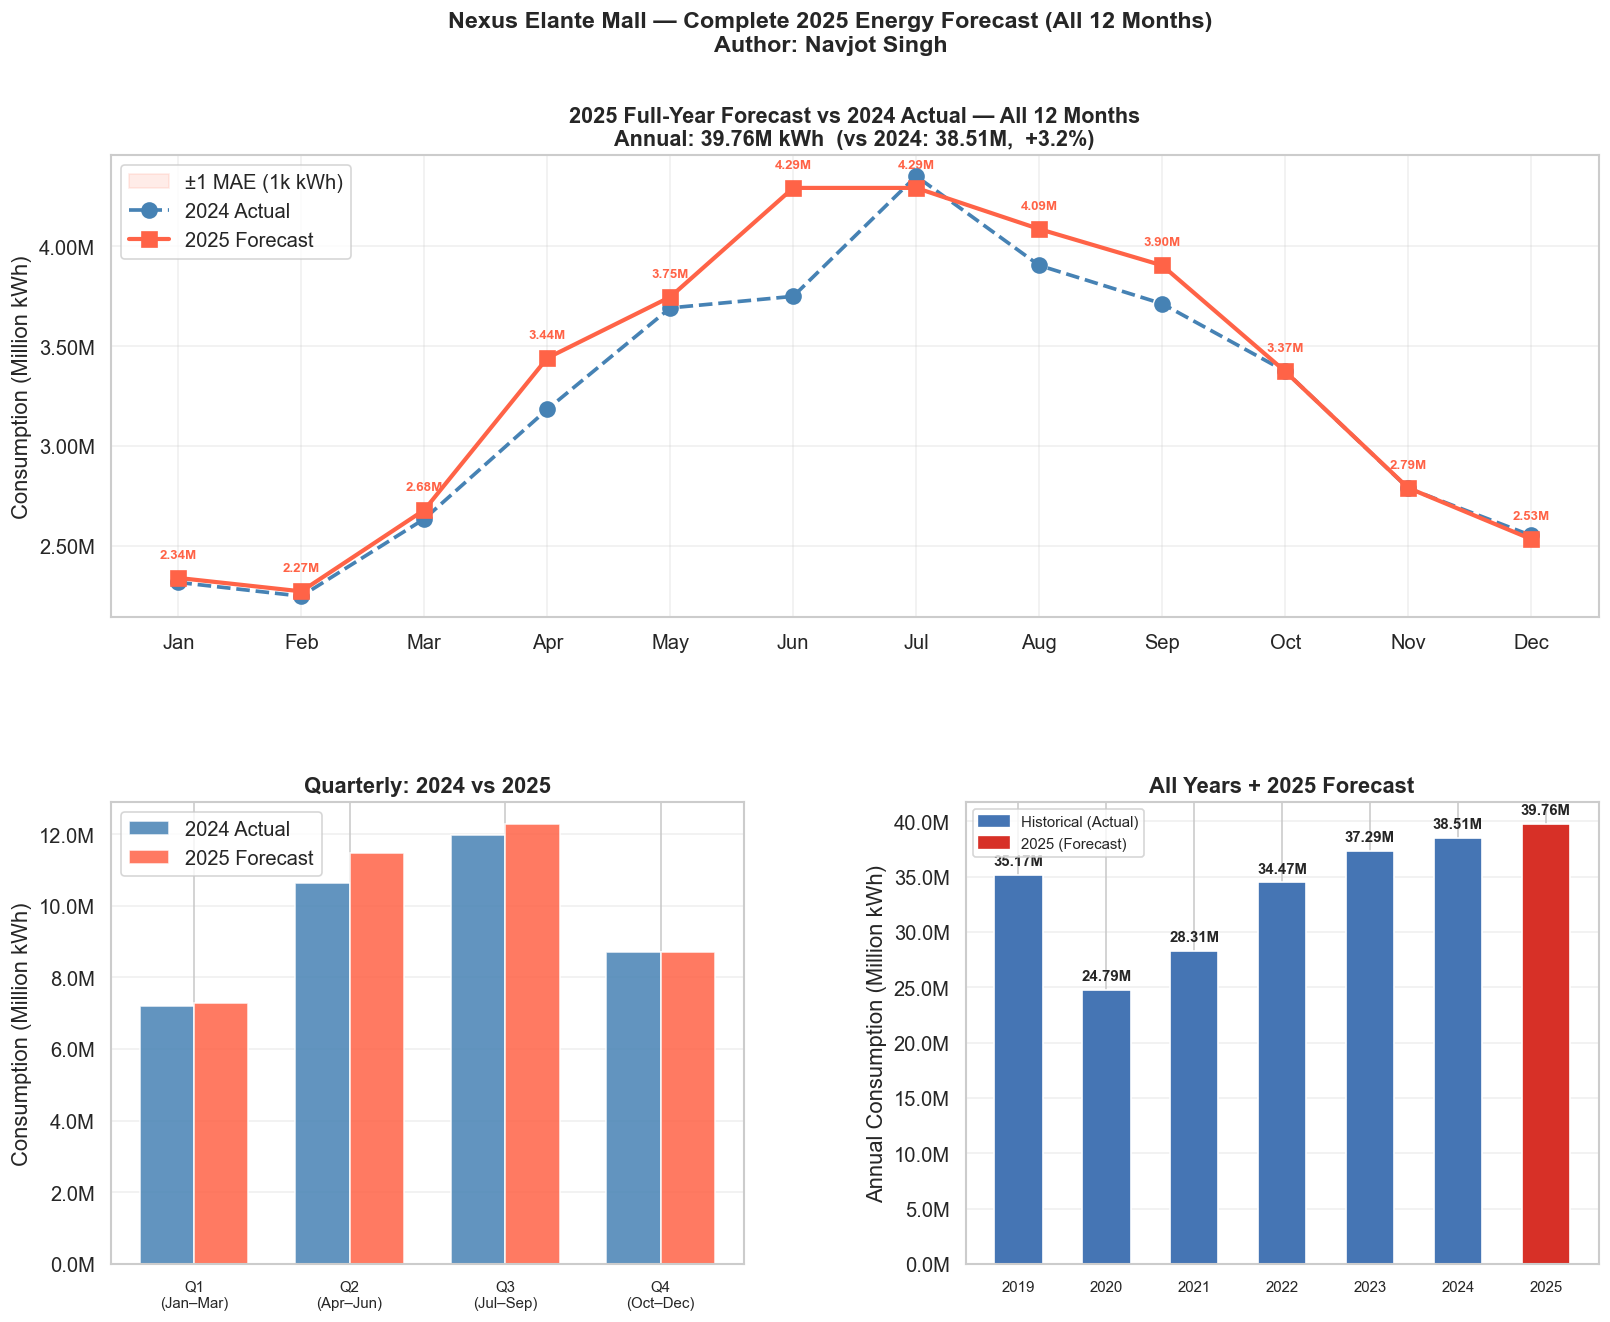


✅  Saved: plot_11_complete_2025_forecast.png


In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
#  COMPLETE 2025 FULL-YEAR FORECAST — Navjot Singh
#  Nexus Elante Mall, Chandigarh
#  FIX: Forces 2024 as the base year (2025 file only has 6 months so far)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import RidgeCV
from sklearn.ensemble      import GradientBoostingRegressor
from sklearn.metrics       import r2_score, mean_absolute_error

MONTH_ORDER = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

# ── KEY FIX: pick the most recent year that has all 12 months ─────────────────
base_year = None
for yr in sorted(cleaned.keys(), reverse=True):
    df_check   = cleaned[yr]
    valid_rows = (df_check[df_check['Months'].isin(MONTH_ORDER)]
                  .drop_duplicates('Month_Num'))
    if len(valid_rows) == 12:
        base_year = yr
        break

if base_year is None:
    raise ValueError("No year with complete 12 months found in cleaned datasets!")

print(f"✅  Base year for forecast : {base_year}  (12 complete months)")

df_base = (cleaned[base_year]
           [cleaned[base_year]['Months'].isin(MONTH_ORDER)]
           .drop_duplicates('Month_Num')
           .sort_values('Month_Num')
           .reset_index(drop=True))

# ── Feature selection on base year ───────────────────────────────────────────
LEAK_PATTERN = r'(24 to 23|23 to 22|YoY|Bill|Growth|Forecast|pct|change)'
TARGET       = 'Consumption'

def get_features(df, target=TARGET):
    exclude    = {target, 'Year', 'Month_Num', 'Months'}
    candidates = [c for c in df.select_dtypes(include='number').columns
                  if c not in exclude
                  and not re.search(LEAK_PATTERN, c, re.IGNORECASE)]
    if not candidates:
        return []
    max_f = max(3, len(df) // 3)
    corrs = df[candidates].corrwith(df[target]).abs().sort_values(ascending=False)
    return corrs.head(max_f).index.tolist()

base_features = get_features(df_base)
print(f"    Features used     : {base_features}")

X_base = df_base[base_features].values
y_base = df_base[TARGET].values

# ── Train both models on base year ────────────────────────────────────────────
alphas = np.logspace(-2, 6, 60)
pipe_r = Pipeline([('sc', StandardScaler()), ('r', RidgeCV(alphas=alphas))])
pipe_r.fit(X_base, y_base)

pipe_g = Pipeline([('sc', StandardScaler()),
                   ('r', GradientBoostingRegressor(
                       n_estimators=100, max_depth=2,
                       learning_rate=0.08, subsample=0.9, random_state=42))])
pipe_g.fit(X_base, y_base)

r2_r = r2_score(y_base, pipe_r.predict(X_base))
r2_g = r2_score(y_base, pipe_g.predict(X_base))
best_pipe_f  = pipe_g if r2_g >= r2_r else pipe_r
best_label_f = 'Gradient Boosting' if r2_g >= r2_r else 'Ridge'
mae          = mean_absolute_error(y_base, best_pipe_f.predict(X_base))
print(f"    Model selected    : {best_label_f}  (R²={max(r2_r,r2_g):.4f})")
print(f"    MAE (in-sample)   : {mae:,.0f} kWh")

# ── YoY growth factor — only from years with full 12 months ──────────────────
full_year_totals = {}
for yr in sorted(cleaned.keys()):
    df_yr = cleaned[yr]
    rows  = (df_yr[df_yr['Months'].isin(MONTH_ORDER)]
             .drop_duplicates('Month_Num'))
    if len(rows) == 12 and 'Consumption' in rows.columns:
        full_year_totals[yr] = rows['Consumption'].sum()

full_sorted = sorted(full_year_totals.items())
if len(full_sorted) >= 2:
    yoy_factor = full_sorted[-1][1] / full_sorted[-2][1]
    print(f"    YoY factor        : {yoy_factor:.4f}  "
          f"({full_sorted[-2][0]} → {full_sorted[-1][0]},  "
          f"{(yoy_factor-1)*100:+.2f}%)")
else:
    yoy_factor = 1.03
    print(f"    YoY factor        : 1.03 (fallback)")

# ── Forecast ──────────────────────────────────────────────────────────────────
X_2025     = df_base[base_features].values * yoy_factor
y_2025     = best_pipe_f.predict(X_2025)
y_2024     = df_base[TARGET].values
months_lbl = df_base['Months'].tolist()
n          = len(months_lbl)

print(f"\n✅  Forecast generated for {n} months")

# ── Quarter mapping ───────────────────────────────────────────────────────────
qmap     = {1:'Q1',2:'Q1',3:'Q1',4:'Q2',5:'Q2',6:'Q2',
            7:'Q3',8:'Q3',9:'Q3',10:'Q4',11:'Q4',12:'Q4'}
quarters = df_base['Month_Num'].map(qmap).tolist()

# ── Forecast DataFrame ────────────────────────────────────────────────────────
forecast_df = pd.DataFrame({
    'Month'        : months_lbl,
    'Quarter'      : quarters,
    'Actual_2024'  : y_2024.astype(int),
    'Forecast_2025': y_2025.astype(int),
    'Change_kWh'   : (y_2025 - y_2024).astype(int),
    'Change_pct'   : ((y_2025 - y_2024) / y_2024 * 100).round(2),
    'Low_2025'     : (y_2025 - mae).astype(int),
    'High_2025'    : (y_2025 + mae).astype(int),
})

def status(pct):
    if pct >  5: return '🔴 High Increase'
    if pct >  0: return '🟡 Slight Increase'
    if pct > -5: return '🟢 Slight Decrease'
    return '🟢 Good Decrease'

forecast_df['Status'] = forecast_df['Change_pct'].apply(status)

# ── Print monthly table ───────────────────────────────────────────────────────
print("\n" + "=" * 90)
print(f"  2025 COMPLETE MONTHLY FORECAST — Navjot Singh | Nexus Elante Mall, Chandigarh")
print("=" * 90)
print(f"  {'Month':<12} {'2024 Actual':>14} {'2025 Forecast':>15} "
      f"{'Low':>14} {'High':>14} {'Change %':>9}  Status")
print("-" * 90)
for _, row in forecast_df.iterrows():
    print(f"  {row['Month']:<12} {row['Actual_2024']:>14,} {row['Forecast_2025']:>15,} "
          f"{row['Low_2025']:>14,} {row['High_2025']:>14,} "
          f"{row['Change_pct']:>+8.1f}%  {row['Status']}")
print("-" * 90)

# ── Quarterly breakdown ───────────────────────────────────────────────────────
q_order   = [q for q in ['Q1','Q2','Q3','Q4'] if q in forecast_df['Quarter'].values]
q_summary = (forecast_df.groupby('Quarter', sort=False)
             .agg(Actual_2024=('Actual_2024','sum'),
                  Forecast_2025=('Forecast_2025','sum'))
             .reindex(q_order).reset_index())
q_summary['Change_pct'] = ((q_summary['Forecast_2025'] - q_summary['Actual_2024'])
                            / q_summary['Actual_2024'] * 100).round(2)

print(f"\n  QUARTERLY BREAKDOWN")
print("-" * 55)
print(f"  {'Quarter':<10} {'2024 Actual':>14} {'2025 Forecast':>15} {'Change %':>9}")
print("-" * 55)
for _, row in q_summary.iterrows():
    print(f"  {row['Quarter']:<10} {row['Actual_2024']:>14,} "
          f"{row['Forecast_2025']:>15,}   {row['Change_pct']:+.2f}%")

# ── Annual totals ─────────────────────────────────────────────────────────────
total_2024 = int(y_2024.sum())
total_2025 = int(y_2025.sum())
chg_abs    = total_2025 - total_2024
chg_pct    = chg_abs / total_2024 * 100

print(f"\n  ANNUAL TOTALS")
print("-" * 55)
print(f"  {base_year} Actual         : {total_2024:>15,} kWh  ({total_2024/1e6:.3f} M)")
print(f"  2025 Forecast          : {total_2025:>15,} kWh  ({total_2025/1e6:.3f} M)")
print(f"  Low  (−1 MAE × 12)    : {int((y_2025-mae).sum()):>15,} kWh")
print(f"  High (+1 MAE × 12)    : {int((y_2025+mae).sum()):>15,} kWh")
print(f"  Change vs {base_year}       : {chg_abs:>+15,} kWh  ({chg_pct:+.2f}%)")

tariff = 8
print(f"\n  ENERGY COST ESTIMATE  (@ ₹{tariff}/kWh)")
print(f"  {base_year} Cost         : ₹ {total_2024*tariff:>15,}")
print(f"  2025 Projected Cost    : ₹ {total_2025*tariff:>15,}")
print(f"  Difference             : ₹ {chg_abs*tariff:>+15,}")

# ── Historical comparison ─────────────────────────────────────────────────────
hist       = pd.Series(full_year_totals).sort_index()
hist[2025] = total_2025
hist       = hist.sort_index()

print(f"\n  FULL HISTORICAL + 2025 FORECAST")
print("-" * 45)
prev = None
for yr, val in hist.items():
    tag = " ← FORECAST" if yr == 2025 else ""
    if prev:
        g = (val - prev) / prev * 100
        print(f"  {yr}:  {val:>12,} kWh  ({g:+.1f}% YoY){tag}")
    else:
        print(f"  {yr}:  {val:>12,} kWh{tag}")
    prev = val
print("=" * 90)

# ── Charts ────────────────────────────────────────────────────────────────────
x_pos = np.arange(n)
fig   = plt.figure(figsize=(16, 12))
gs    = GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Chart A — Full 12-month forecast
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(x_pos, (y_2025-mae)/1e6, (y_2025+mae)/1e6,
                 color='tomato', alpha=0.12, label=f'±1 MAE ({mae/1e3:,.0f}k kWh)')
ax1.plot(x_pos, y_2024/1e6, 'o--', color='steelblue',
         linewidth=2.2, markersize=9, label=f'{base_year} Actual', zorder=4)
ax1.plot(x_pos, y_2025/1e6, 's-',  color='tomato',
         linewidth=2.5, markersize=9, label='2025 Forecast', zorder=4)
for xi, yi in zip(x_pos, y_2025):
    ax1.annotate(f"{yi/1e6:.2f}M", (xi, yi/1e6),
                 textcoords='offset points', xytext=(0, 12),
                 ha='center', fontsize=8, color='tomato', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([m[:3] for m in months_lbl])
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.2f}M"))
ax1.set_title(f'2025 Full-Year Forecast vs {base_year} Actual — All 12 Months\n'
              f'Annual: {total_2025/1e6:.2f}M kWh  '
              f'(vs {base_year}: {total_2024/1e6:.2f}M,  {chg_pct:+.1f}%)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Consumption (Million kWh)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Chart B — Quarterly
ax2 = fig.add_subplot(gs[1, 0])
xq, w = np.arange(len(q_summary)), 0.35
ax2.bar(xq-w/2, q_summary['Actual_2024']/1e6,   width=w, color='steelblue',
        alpha=0.85, edgecolor='white', label=f'{base_year} Actual')
ax2.bar(xq+w/2, q_summary['Forecast_2025']/1e6, width=w, color='tomato',
        alpha=0.85, edgecolor='white', label='2025 Forecast')
ax2.set_xticks(xq)
ax2.set_xticklabels(['Q1\n(Jan–Mar)','Q2\n(Apr–Jun)',
                     'Q3\n(Jul–Sep)','Q4\n(Oct–Dec)'], fontsize=9)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.1f}M"))
ax2.set_title(f'Quarterly: {base_year} vs 2025', fontweight='bold')
ax2.set_ylabel('Consumption (Million kWh)')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

# Chart C — All years
ax3 = fig.add_subplot(gs[1, 1])
bar_cols = ['#4575b4'] * (len(hist)-1) + ['#d73027']
bars3 = ax3.bar([str(y) for y in hist.index], hist.values/1e6,
                color=bar_cols, width=0.55, edgecolor='white')
ax3.bar_label(bars3, fmt=lambda x: f"{x:.2f}M", padding=4, fontsize=9, fontweight='bold')
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x:.1f}M"))
ax3.set_title('All Years + 2025 Forecast', fontweight='bold')
ax3.set_ylabel('Annual Consumption (Million kWh)')
ax3.tick_params(axis='x', labelsize=9)
ax3.grid(axis='y', alpha=0.3)
ax3.legend(handles=[
    mpatches.Patch(color='#4575b4', label='Historical (Actual)'),
    mpatches.Patch(color='#d73027', label='2025 (Forecast)'),
], fontsize=9)

fig.suptitle('Nexus Elante Mall — Complete 2025 Energy Forecast (All 12 Months)\n'
             'Author: Navjot Singh', fontsize=14, fontweight='bold')
plt.savefig('plot_11_complete_2025_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅  Saved: plot_11_complete_2025_forecast.png")